In [176]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
ai4i_2020_predictive_maintenance_dataset = fetch_ucirepo(id=601) 
  
# data (as pandas dataframes) 
X = ai4i_2020_predictive_maintenance_dataset.data.features 
y = ai4i_2020_predictive_maintenance_dataset.data.targets 
  
# metadata 
print(ai4i_2020_predictive_maintenance_dataset.metadata) 
  
# variable information 
print(ai4i_2020_predictive_maintenance_dataset.variables) 


{'uci_id': 601, 'name': 'AI4I 2020 Predictive Maintenance Dataset', 'repository_url': 'https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/601/data.csv', 'abstract': 'The AI4I 2020 Predictive Maintenance Dataset is a synthetic dataset that reflects real predictive maintenance data encountered in industry.', 'area': 'Computer Science', 'tasks': ['Classification', 'Regression', 'Causal-Discovery'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 10000, 'num_features': 6, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], 'index_col': ['UID', 'Product ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Wed Feb 14 2024', 'dataset_doi': '10.24432/C5HS5C', 'creators': [], 'intro_paper': {'ID': 386, 'type': 'NATIVE', 'title': 'Explainable Artificial Intelligen

## Imports

In [177]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

## Logistic Regression
from sklearn.linear_model import LogisticRegression

## Decision Tree
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

## MLP Regressor
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from torch.utils.data import TensorDataset, DataLoader

## Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

## Gradient Boosting
from xgboost import XGBClassifier

## SVM
from sklearn import svm


 

## Informative Data

In [178]:
X = ai4i_2020_predictive_maintenance_dataset.data.features.copy()
targets = ai4i_2020_predictive_maintenance_dataset.data.targets.copy()

y = targets["Machine failure"].copy()

print(X.head())
print(X.shape, y.shape)
print(X.columns)
print(X.describe())

print("Target : Machine Failure or not")
print(y.head())
print(y.describe())

print(y.value_counts())

  Type  Air temperature  Process temperature  Rotational speed  Torque  \
0    M            298.1                308.6              1551    42.8   
1    L            298.2                308.7              1408    46.3   
2    L            298.1                308.5              1498    49.4   
3    L            298.2                308.6              1433    39.5   
4    L            298.2                308.7              1408    40.0   

   Tool wear  
0          0  
1          3  
2          5  
3          7  
4          9  
(10000, 6) (10000,)
Index(['Type', 'Air temperature', 'Process temperature', 'Rotational speed',
       'Torque', 'Tool wear'],
      dtype='object')
       Air temperature  Process temperature  Rotational speed        Torque  \
count     10000.000000         10000.000000      10000.000000  10000.000000   
mean        300.004930           310.005560       1538.776100     39.986910   
std           2.000259             1.483734        179.284096      9.968934   

## Cleaning Data and Train, Test Split

In [179]:
X = pd.get_dummies(X, columns=["Type"], drop_first=True)

print(X.head())
print(X.shape)
print(X.dtypes)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)
standardScaler = StandardScaler()

X_train_scaled = standardScaler.fit_transform(X_train)
X_val_scaled = standardScaler.transform(X_val)
X_test_scaled = standardScaler.transform(X_test)

print("Train:", X_train.shape, y_train.value_counts(normalize=True))
print("Val:", X_val.shape, y_val.value_counts(normalize=True))
print("Test:", X_test.shape, y_test.value_counts(normalize=True))

## Note: The data is heavily imbalanced. We will need to use techniques to handle this imbalance, such as Recall and other metrics, resampling techniques, or algorithms that are robust to imbalanced data.

   Air temperature  Process temperature  Rotational speed  Torque  Tool wear  \
0            298.1                308.6              1551    42.8          0   
1            298.2                308.7              1408    46.3          3   
2            298.1                308.5              1498    49.4          5   
3            298.2                308.6              1433    39.5          7   
4            298.2                308.7              1408    40.0          9   

   Type_L  Type_M  
0   False    True  
1    True   False  
2    True   False  
3    True   False  
4    True   False  
(10000, 7)
Air temperature        float64
Process temperature    float64
Rotational speed         int64
Torque                 float64
Tool wear                int64
Type_L                    bool
Type_M                    bool
dtype: object
Train: (6000, 7) Machine failure
0    0.966167
1    0.033833
Name: proportion, dtype: float64
Val: (2000, 7) Machine failure
0    0.966
1    0.034
Name: prop

## Logistic Regression

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.69      0.13      0.22        68

    accuracy                           0.97      2000
   macro avg       0.83      0.57      0.60      2000
weighted avg       0.96      0.97      0.96      2000

ROC-AUC: 0.9001568018511753
[[1928    4]
 [  59    9]]


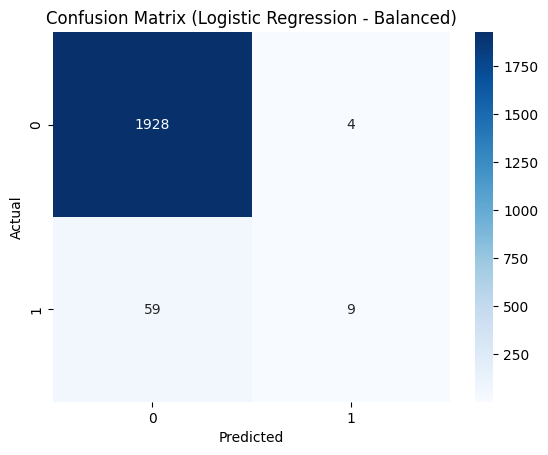

In [180]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Logistic Regression - Balanced)")
plt.show()

              precision    recall  f1-score   support

           0       0.99      0.83      0.91      1932
           1       0.15      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.58      2000
weighted avg       0.96      0.83      0.88      2000

ROC-AUC: 0.9037114845938377
              precision    recall  f1-score   support

           0       0.99      0.83      0.91      1932
           1       0.15      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.58      2000
weighted avg       0.96      0.83      0.88      2000

[[1607  325]
 [  12   56]]


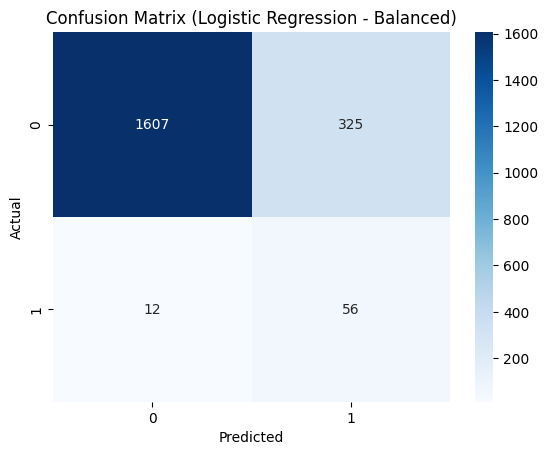

In [181]:
# classes balaced using class_weight='balanced'
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = lr_balanced.predict(X_test_scaled)
y_prob_balanced = lr_balanced.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_balanced))
print(classification_report(y_test, y_pred_balanced))
cm = confusion_matrix(y_test, y_pred_balanced)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Logistic Regression - Balanced)")
plt.show()


        C  precision    recall        f1   roc_auc
0    0.01   0.136816  0.808824  0.234043  0.870867
1    0.10   0.141772  0.823529  0.241901  0.878509
2    0.30   0.141772  0.823529  0.241901  0.878753
3    0.50   0.142494  0.823529  0.242950  0.878768
4    0.70   0.142857  0.823529  0.243478  0.878753
5    0.90   0.142494  0.823529  0.242950  0.878798
6    1.00   0.142494  0.823529  0.242950  0.878821
7   10.00   0.143223  0.823529  0.244009  0.878897
8  100.00   0.142857  0.823529  0.243478  0.878905
        C  precision    recall        f1   roc_auc
7   10.00   0.143223  0.823529  0.244009  0.878897
8  100.00   0.142857  0.823529  0.243478  0.878905
4    0.70   0.142857  0.823529  0.243478  0.878753
6    1.00   0.142494  0.823529  0.242950  0.878821
3    0.50   0.142494  0.823529  0.242950  0.878768
5    0.90   0.142494  0.823529  0.242950  0.878798
1    0.10   0.141772  0.823529  0.241901  0.878509
2    0.30   0.141772  0.823529  0.241901  0.878753
0    0.01   0.136816  0.808824 

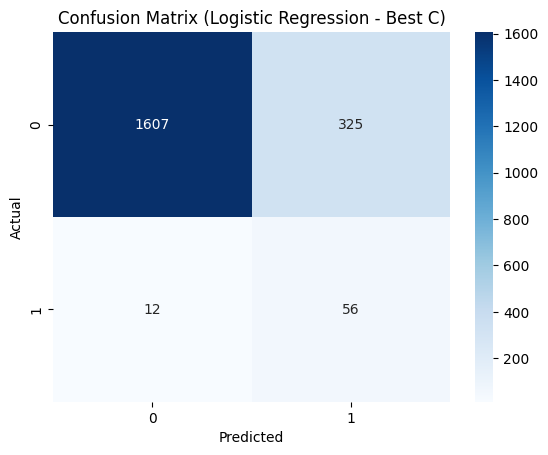

In [182]:
C_values = [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1, 10, 100]
lr_results = []

for C in C_values:
    lr = LogisticRegression(
        C=C,
        max_iter=1000,
        class_weight="balanced"
    )

    lr.fit(X_train_scaled, y_train)

    y_val_pred = lr.predict(X_val_scaled)
    y_val_prob = lr.predict_proba(X_val_scaled)[:, 1]

    lr_results.append({
        "C": C,
        "precision": precision_score(y_val, y_val_pred),
        "recall": recall_score(y_val, y_val_pred),
        "f1": f1_score(y_val, y_val_pred),
        "roc_auc": roc_auc_score(y_val, y_val_prob)
    })

lr_results_df = pd.DataFrame(lr_results)
print(lr_results_df)

print(lr_results_df.sort_values("f1", ascending=False))

best_C = 10  # from validation

lr_best = LogisticRegression(
    C=best_C,
    max_iter=1000,
    class_weight="balanced"
)

lr_best.fit(X_train_scaled, y_train)
y_test_pred = lr_best.predict(X_test_scaled)
y_test_prob = lr_best.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))
cm = confusion_matrix(y_test, y_test_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Logistic Regression - Best C)")
plt.show()



               Feature  Coefficient  abs_coeff
3               Torque     2.460990   2.460990
0      Air temperature     1.840869   1.840869
2     Rotational speed     1.721137   1.721137
1  Process temperature    -1.167661   1.167661
4            Tool wear     0.766605   0.766605
5               Type_L     0.049196   0.049196
6               Type_M    -0.038589   0.038589


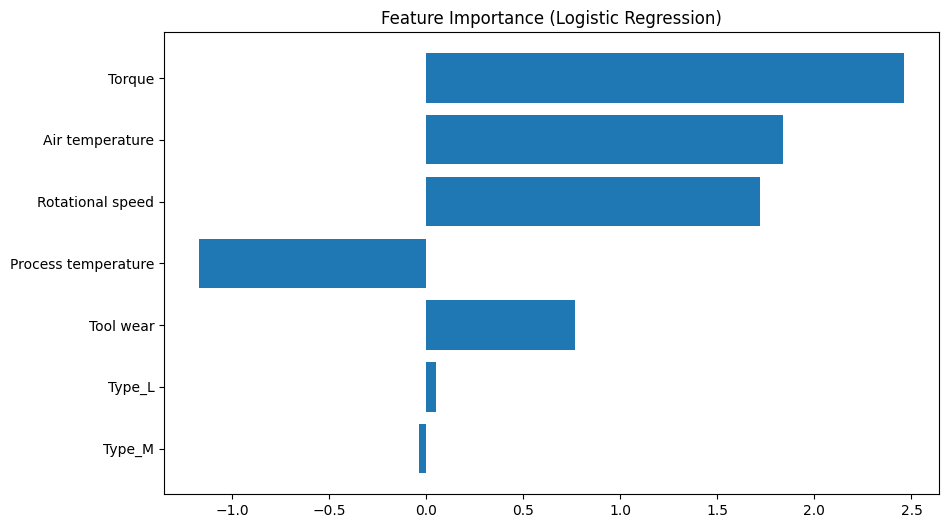

In [183]:
feature_names = X.columns

coefficients = lr_balanced.coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance["abs_coeff"] = importance["Coefficient"].abs()
importance = importance.sort_values(by="abs_coeff", ascending=False)

print(importance)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Coefficient"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Logistic Regression)")
plt.show()


Threshold: 0.10
              precision    recall  f1-score   support

           0       1.00      0.40      0.57      1932
           1       0.05      0.99      0.10        68

    accuracy                           0.42      2000
   macro avg       0.53      0.69      0.34      2000
weighted avg       0.97      0.42      0.56      2000

ROC-AUC: 0.9037114845938375
[[ 776 1156]
 [   1   67]]


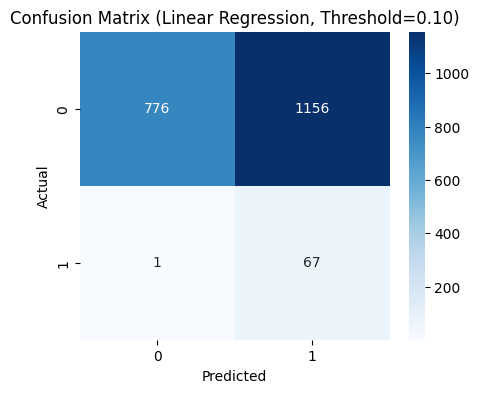


Threshold: 0.20
              precision    recall  f1-score   support

           0       1.00      0.58      0.73      1932
           1       0.07      0.94      0.14        68

    accuracy                           0.59      2000
   macro avg       0.53      0.76      0.43      2000
weighted avg       0.97      0.59      0.71      2000

ROC-AUC: 0.9037114845938375
[[1118  814]
 [   4   64]]


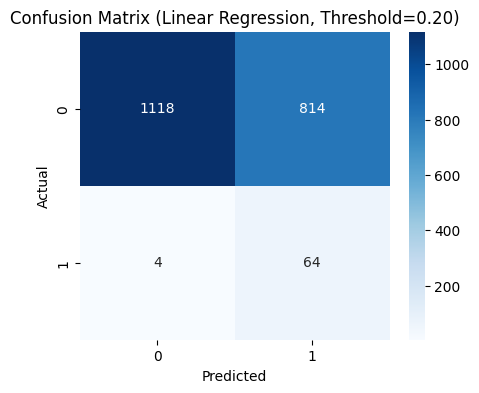


Threshold: 0.30
              precision    recall  f1-score   support

           0       0.99      0.69      0.81      1932
           1       0.09      0.90      0.17        68

    accuracy                           0.70      2000
   macro avg       0.54      0.79      0.49      2000
weighted avg       0.96      0.70      0.79      2000

ROC-AUC: 0.9037114845938375
[[1333  599]
 [   7   61]]


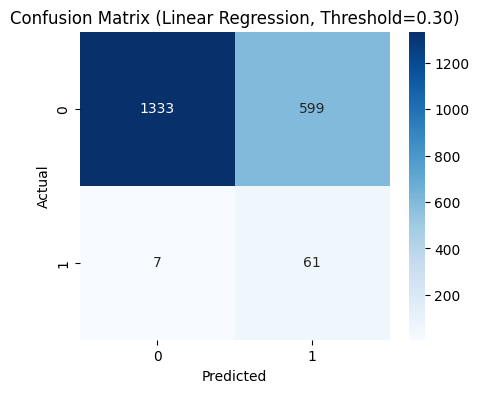


Threshold: 0.40
              precision    recall  f1-score   support

           0       0.99      0.77      0.87      1932
           1       0.12      0.88      0.21        68

    accuracy                           0.77      2000
   macro avg       0.56      0.83      0.54      2000
weighted avg       0.96      0.77      0.85      2000

ROC-AUC: 0.9037114845938375
[[1487  445]
 [   8   60]]


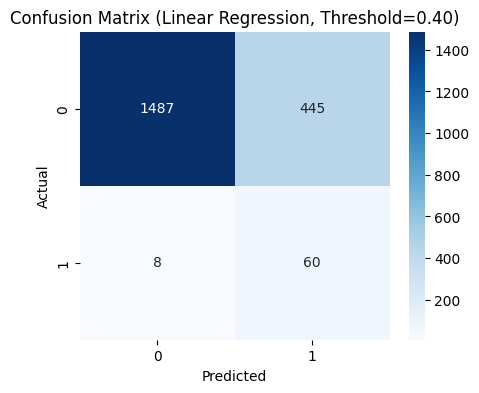


Threshold: 0.50
              precision    recall  f1-score   support

           0       0.99      0.83      0.91      1932
           1       0.15      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.58      2000
weighted avg       0.96      0.83      0.88      2000

ROC-AUC: 0.9037114845938375
[[1607  325]
 [  12   56]]


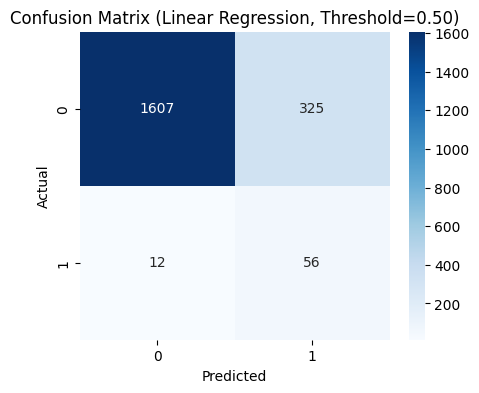


Threshold: 0.60
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1932
           1       0.18      0.76      0.29        68

    accuracy                           0.87      2000
   macro avg       0.58      0.82      0.61      2000
weighted avg       0.96      0.87      0.91      2000

ROC-AUC: 0.9037114845938375
[[1694  238]
 [  16   52]]


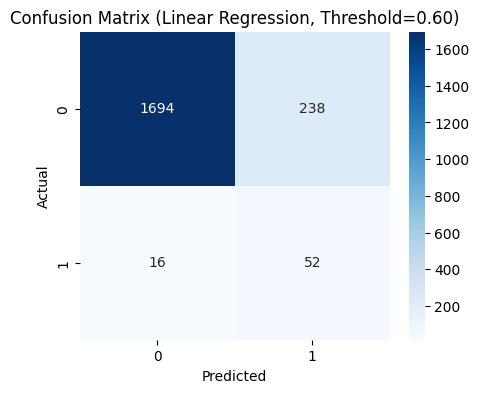


Threshold: 0.70
              precision    recall  f1-score   support

           0       0.99      0.92      0.96      1932
           1       0.24      0.69      0.36        68

    accuracy                           0.92      2000
   macro avg       0.62      0.81      0.66      2000
weighted avg       0.96      0.92      0.93      2000

ROC-AUC: 0.9037114845938375
[[1785  147]
 [  21   47]]


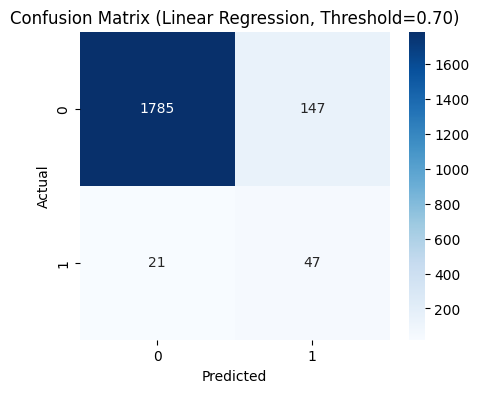


Threshold: 0.80
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1932
           1       0.31      0.53      0.39        68

    accuracy                           0.94      2000
   macro avg       0.65      0.74      0.68      2000
weighted avg       0.96      0.94      0.95      2000

ROC-AUC: 0.9037114845938375
[[1853   79]
 [  32   36]]


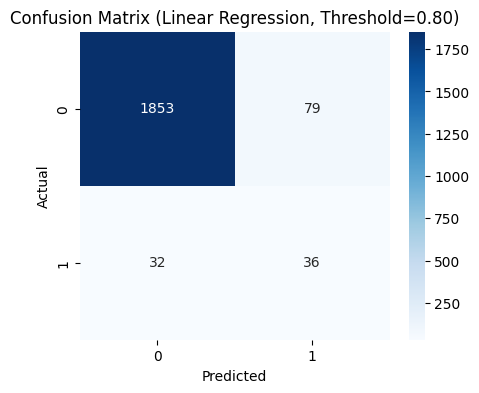


Threshold: 0.90
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1932
           1       0.44      0.34      0.38        68

    accuracy                           0.96      2000
   macro avg       0.71      0.66      0.68      2000
weighted avg       0.96      0.96      0.96      2000

ROC-AUC: 0.9037114845938375
[[1903   29]
 [  45   23]]


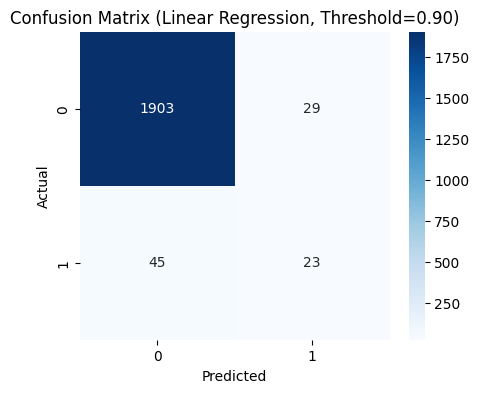

In [184]:
for t in np.linspace(0.1, 0.9, 9):
    preds = (y_test_prob >= t).astype(int)

    print(f"\nThreshold: {t:.2f}")
    print(classification_report(y_test, preds, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))
    cm = confusion_matrix(y_test, preds)
    print(cm)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix (Linear Regression, Threshold={t:.2f})")
    plt.show()

## Using Decision Trees

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.81      0.31      0.45        68

    accuracy                           0.97      2000
   macro avg       0.89      0.65      0.72      2000
weighted avg       0.97      0.97      0.97      2000

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.81      0.31      0.45        68

    accuracy                           0.97      2000
   macro avg       0.89      0.65      0.72      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9297131896236754
[[1927    5]
 [  47   21]]


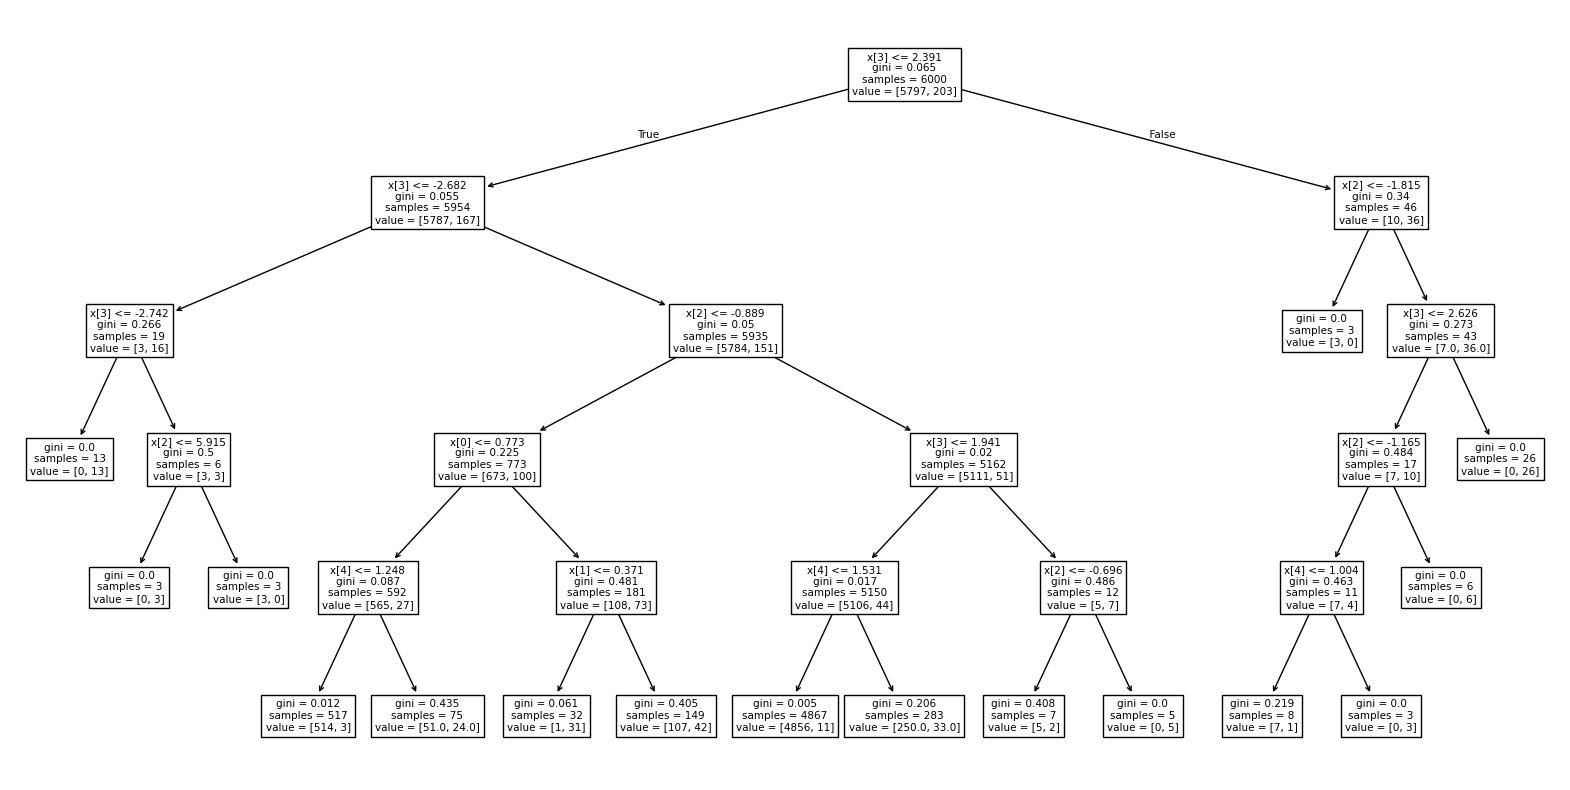

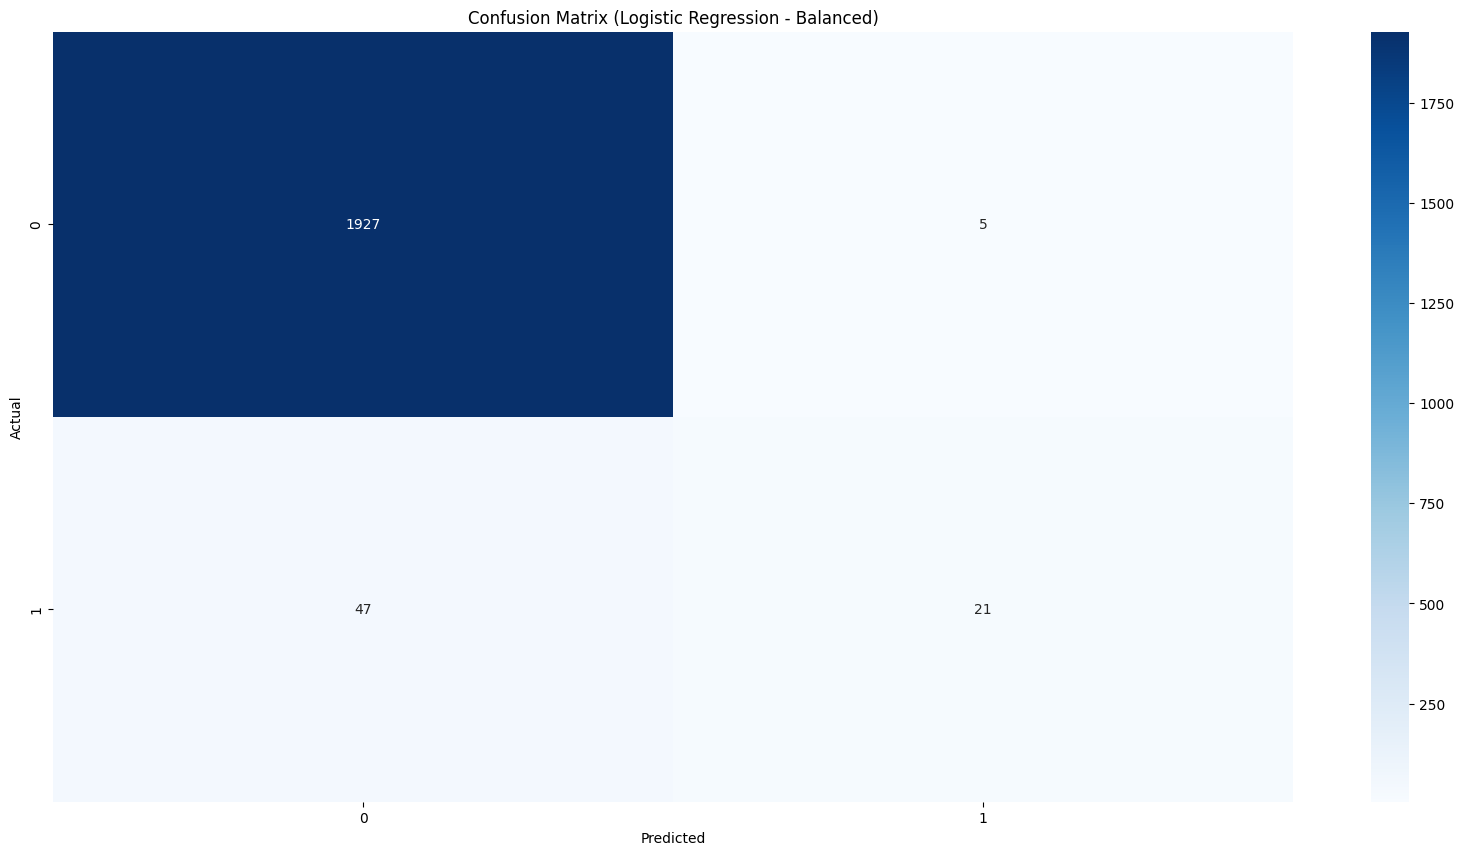

In [185]:
from matplotlib.pyplot import figure
from sklearn import tree


Decision_tree = DecisionTreeClassifier(max_depth = 5, random_state=42)
Decision_tree.fit(X_train_scaled, y_train)
y_pred_dt = Decision_tree.predict(X_test_scaled)
y_prob_dt = Decision_tree.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred_dt))

figure(figsize=(20,10))
tree.plot_tree(Decision_tree)
figure(figsize=(20,10))
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
cm = confusion_matrix(y_test, y_pred_dt)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Logistic Regression - Balanced)")
plt.show()


              precision    recall  f1-score   support

           0       0.99      0.94      0.97      1932
           1       0.34      0.85      0.49        68

    accuracy                           0.94      2000
   macro avg       0.67      0.90      0.73      2000
weighted avg       0.97      0.94      0.95      2000

              precision    recall  f1-score   support

           0       0.99      0.94      0.97      1932
           1       0.34      0.85      0.49        68

    accuracy                           0.94      2000
   macro avg       0.67      0.90      0.73      2000
weighted avg       0.97      0.94      0.95      2000

ROC-AUC: 0.8910189075630252
[[1820  112]
 [  10   58]]


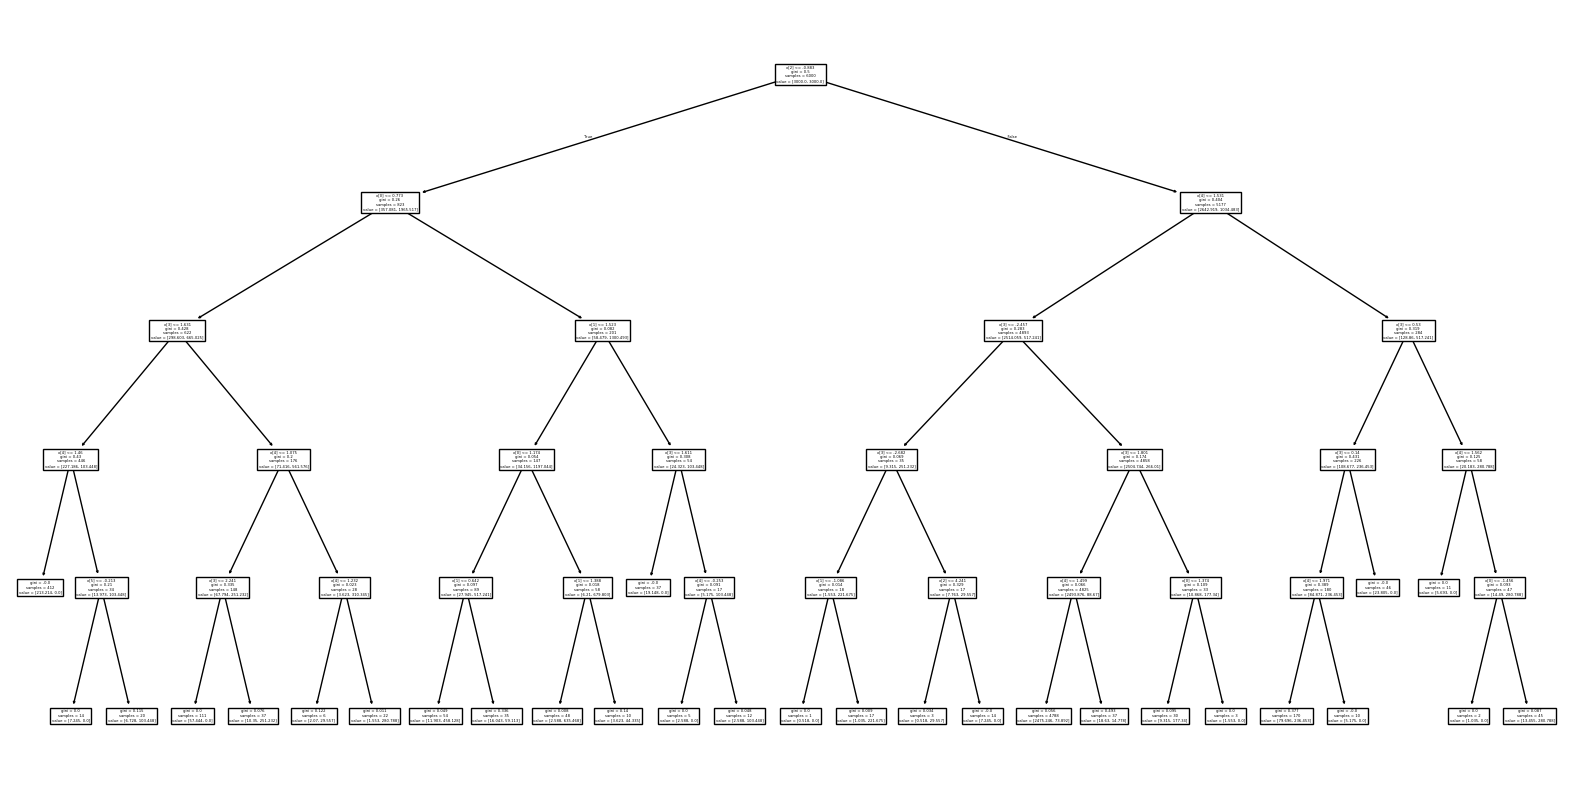

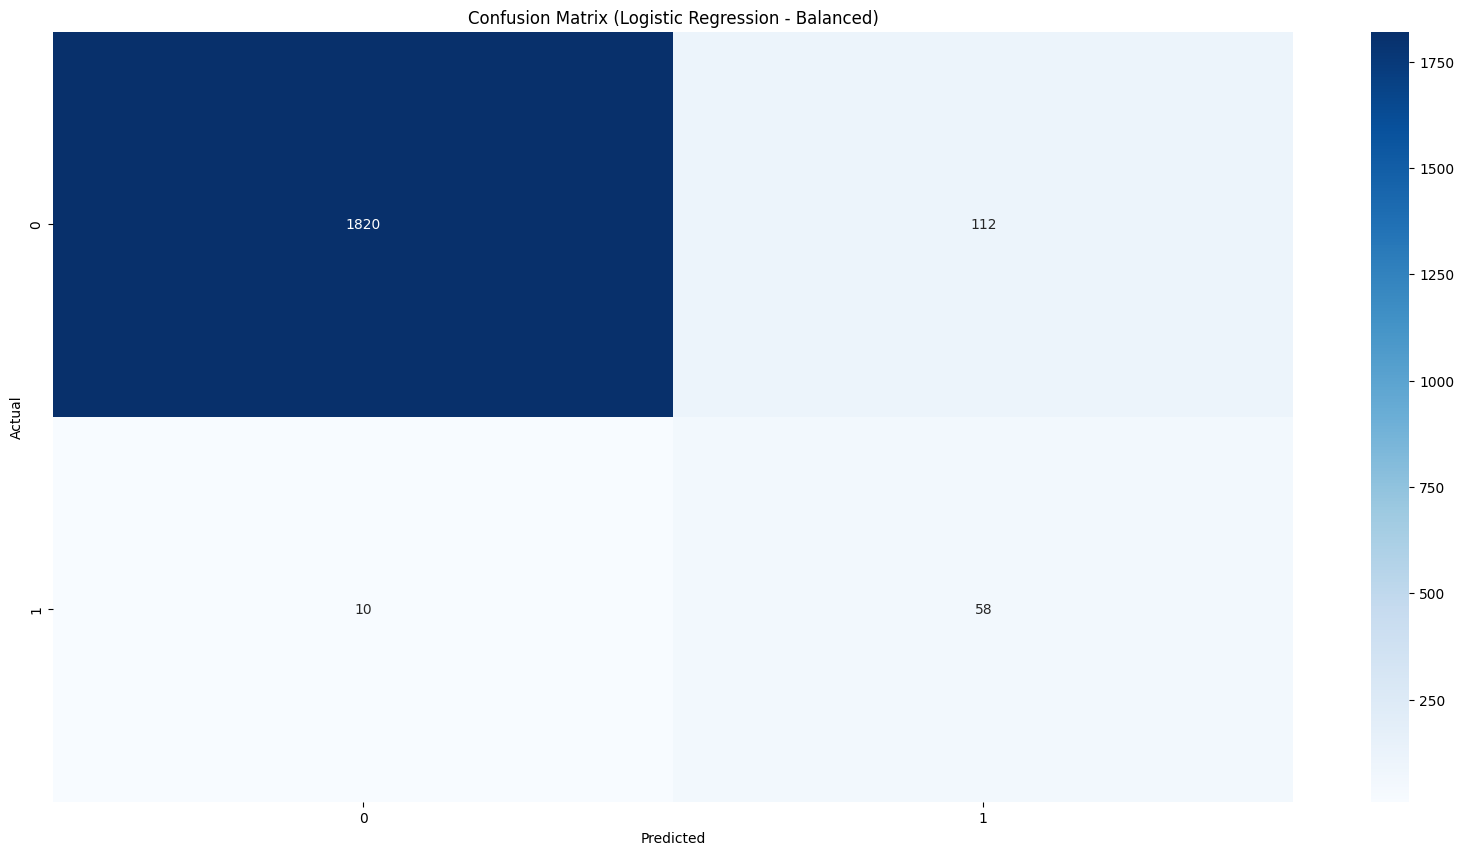

In [186]:
Decision_tree = DecisionTreeClassifier(max_depth = 5, random_state=42, class_weight='balanced')
Decision_tree.fit(X_train_scaled, y_train)
y_pred_dt_balanced = Decision_tree.predict(X_test_scaled)
y_prob_dt_balanced = Decision_tree.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred_dt_balanced))

figure(figsize=(20,10))
tree.plot_tree(Decision_tree)
figure(figsize=(20,10))
print(classification_report(y_test, y_pred_dt_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt_balanced))
cm = confusion_matrix(y_test, y_pred_dt_balanced)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Logistic Regression - Balanced)")
plt.show()


    max_depth  precision    recall        f1   roc_auc
0           1   0.134228  0.588235  0.218579  0.727347
1           2   0.133995  0.794118  0.229299  0.825767
2           3   0.203704  0.808824  0.325444  0.894962
3           4   0.239700  0.941176  0.382090  0.932282
4           5   0.290000  0.852941  0.432836  0.870239
5           6   0.282486  0.735294  0.408163  0.764086
6           7   0.317881  0.705882  0.438356  0.809596
7           8   0.279221  0.632353  0.387387  0.792040
8           9   0.301370  0.647059  0.411215  0.807511
9          10   0.341880  0.588235  0.432432  0.780340
10         11   0.365591  0.500000  0.422360  0.738601
11         12   0.424658  0.455882  0.439716  0.718525
12         13   0.411765  0.411765  0.411765  0.696455
13         14   0.442857  0.455882  0.449275  0.718883
14         15   0.454545  0.441176  0.447761  0.711789
15         16   0.464286  0.382353  0.419355  0.683610
16         17   0.472727  0.382353  0.422764  0.683671
17        

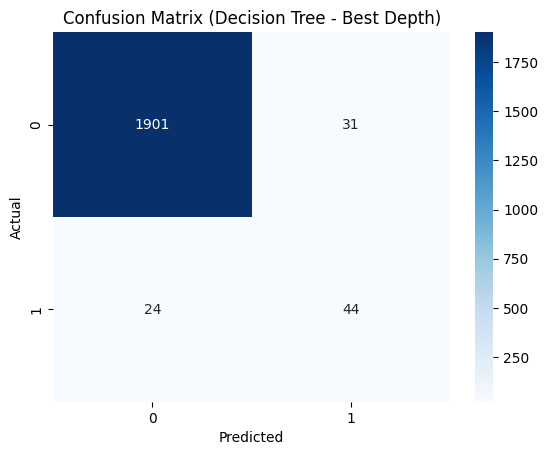

<Figure size 2000x1000 with 0 Axes>

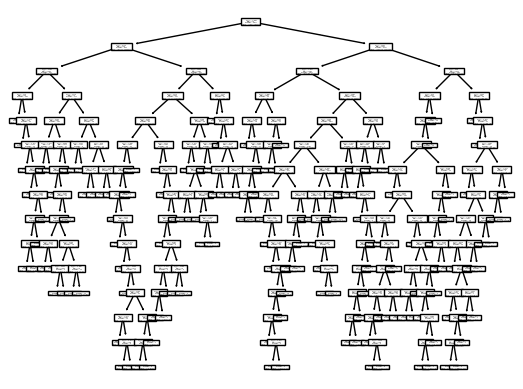

<Figure size 2000x1000 with 0 Axes>

In [187]:
# Validation for Decision Tree
depth_values = list(range(1, 21))
dt_results = []

for depth in depth_values:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42,
        class_weight="balanced"
    )

    dt.fit(X_train_scaled, y_train)

    y_val_pred = dt.predict(X_val_scaled)
    y_val_prob = dt.predict_proba(X_val_scaled)[:, 1]

    dt_results.append({
        "max_depth": depth,
        "precision": precision_score(y_val, y_val_pred),
        "recall": recall_score(y_val, y_val_pred),
        "f1": f1_score(y_val, y_val_pred),
        "roc_auc": roc_auc_score(y_val, y_val_prob)
    })

dt_results_df = pd.DataFrame(dt_results)
print(dt_results_df)
print(dt_results_df.sort_values("f1", ascending=False))


best_depth = int(dt_results_df.sort_values("f1", ascending=False).iloc[0]["max_depth"])
print("Best max_depth:", best_depth)

Decision_tree_best = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42,
    class_weight="balanced"
)
Decision_tree_best.fit(X_train_scaled, y_train)
y_test_pred_dt = Decision_tree_best.predict(X_test_scaled)
y_test_prob_dt = Decision_tree_best.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_test_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_dt))
cm = confusion_matrix(y_test, y_test_pred_dt)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Decision Tree - Best Depth)")
plt.show()

tree.plot_tree(Decision_tree_best)
figure(figsize=(20,10))


               Feature  Importance
3               Torque    0.364347
2     Rotational speed    0.337612
4            Tool wear    0.214813
0      Air temperature    0.049006
1  Process temperature    0.019972
6               Type_M    0.008992
5               Type_L    0.005258


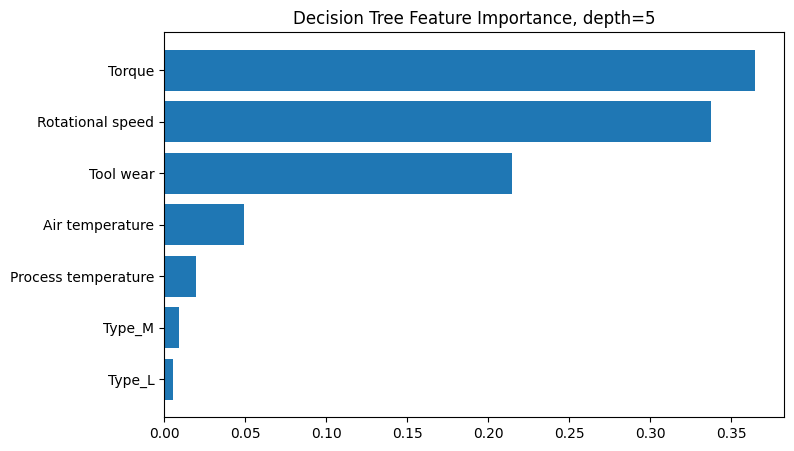


Threshold: 0.10
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.59      0.65      0.62        68

    accuracy                           0.97      2000
   macro avg       0.79      0.82      0.80      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9037114845938375
[[1901   31]
 [  24   44]]


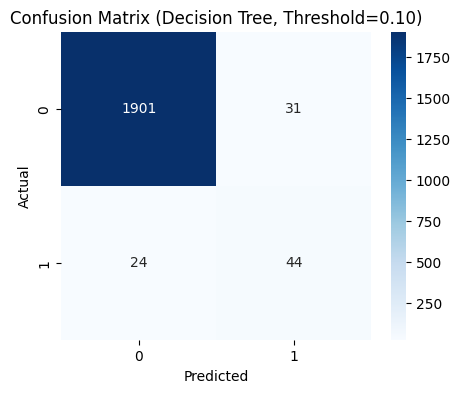


Threshold: 0.20
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.59      0.65      0.62        68

    accuracy                           0.97      2000
   macro avg       0.79      0.82      0.80      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9037114845938375
[[1901   31]
 [  24   44]]


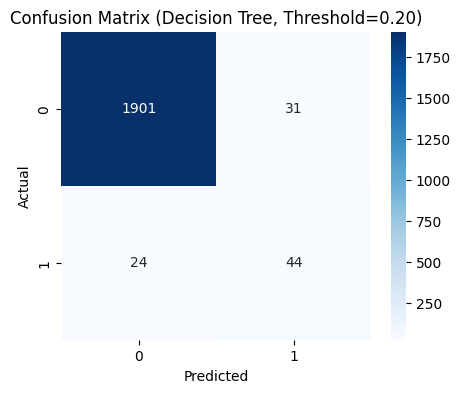


Threshold: 0.30
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.59      0.65      0.62        68

    accuracy                           0.97      2000
   macro avg       0.79      0.82      0.80      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9037114845938375
[[1901   31]
 [  24   44]]


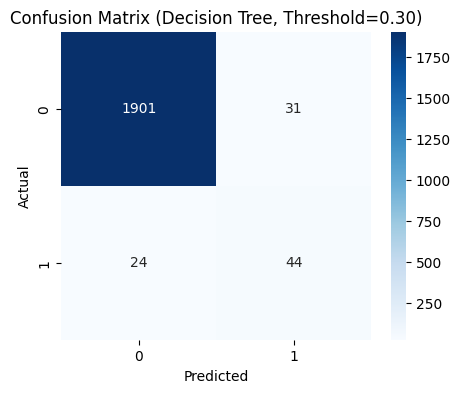


Threshold: 0.40
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.59      0.65      0.62        68

    accuracy                           0.97      2000
   macro avg       0.79      0.82      0.80      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9037114845938375
[[1901   31]
 [  24   44]]


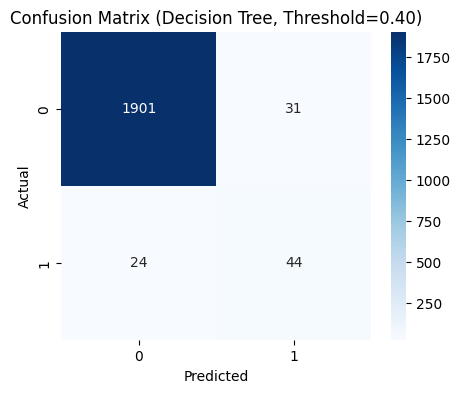


Threshold: 0.50
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.59      0.65      0.62        68

    accuracy                           0.97      2000
   macro avg       0.79      0.82      0.80      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9037114845938375
[[1901   31]
 [  24   44]]


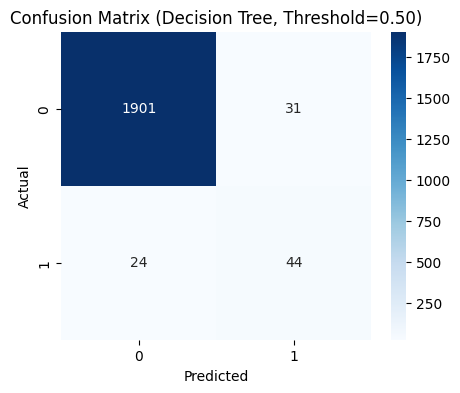


Threshold: 0.60
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.59      0.65      0.62        68

    accuracy                           0.97      2000
   macro avg       0.79      0.82      0.80      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9037114845938375
[[1901   31]
 [  24   44]]


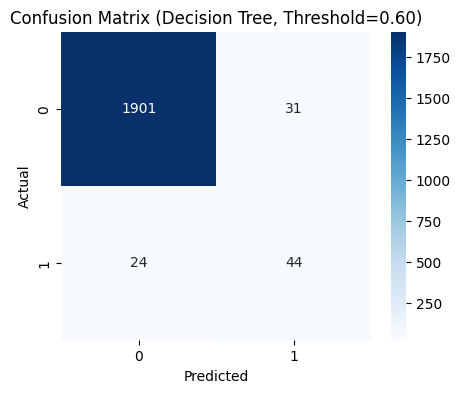


Threshold: 0.70
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.59      0.65      0.62        68

    accuracy                           0.97      2000
   macro avg       0.79      0.82      0.80      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9037114845938375
[[1901   31]
 [  24   44]]


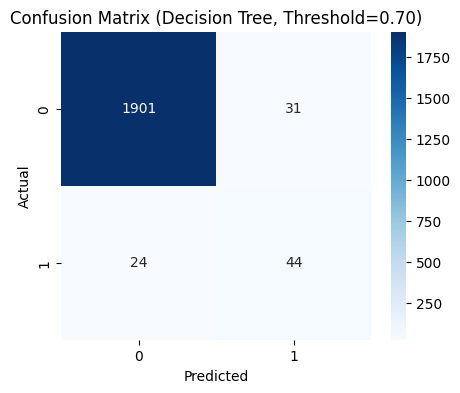


Threshold: 0.80
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.59      0.65      0.62        68

    accuracy                           0.97      2000
   macro avg       0.79      0.82      0.80      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9037114845938375
[[1901   31]
 [  24   44]]


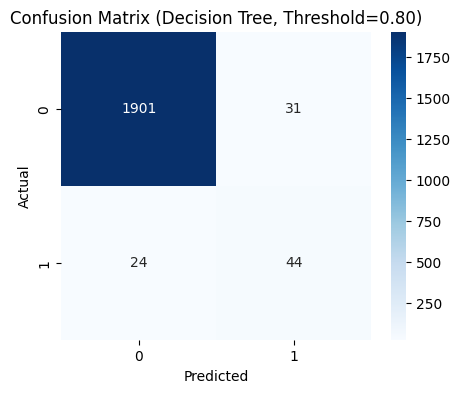


Threshold: 0.90
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.59      0.65      0.62        68

    accuracy                           0.97      2000
   macro avg       0.79      0.82      0.80      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9037114845938375
[[1901   31]
 [  24   44]]


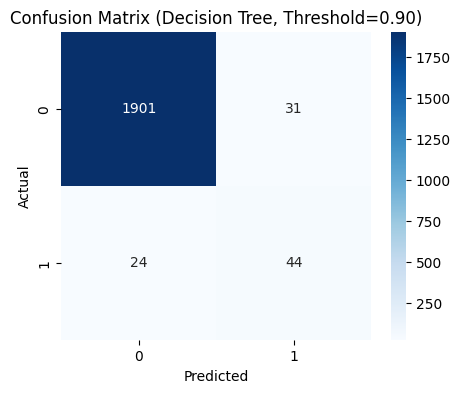

In [206]:
dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": Decision_tree_best.feature_importances_
}).sort_values("Importance", ascending=False)

print(dt_importance)

plt.figure(figsize=(8,5))
plt.barh(dt_importance["Feature"], dt_importance["Importance"])
plt.gca().invert_yaxis()
plt.title(f"Decision Tree Feature Importance, depth={best_depth}")
plt.show()

for t in np.linspace(0.1, 0.9, 9):
    preds = (y_test_prob_dt >= t).astype(int)

    print(f"\nThreshold: {t:.2f}")
    print(classification_report(y_test, preds, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))
    cm = confusion_matrix(y_test, preds)
    print(cm)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix (Decision Tree, Threshold={t:.2f})")
    plt.show()


## MLP Classifier

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.58      0.71      0.64        68

    accuracy                           0.97      2000
   macro avg       0.78      0.84      0.81      2000
weighted avg       0.98      0.97      0.97      2000

ROC-AUC: 0.9619412982584338
[[1897   35]
 [  20   48]]


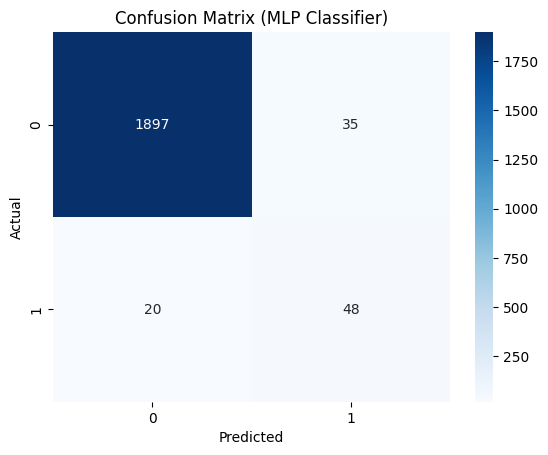

In [189]:
MLP_Class = MLPClassifier(hidden_layer_sizes=(100, 40, 60), activation='relu', solver='adam', alpha=0.0001, batch_size='auto', learning_rate='constant', learning_rate_init=0.001)
MLP_Class.fit(X_train_scaled, y_train)
y_pred_mlp = MLP_Class.predict(X_test_scaled)
y_prob_mlp = MLP_Class.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_mlp))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_mlp))
cm = confusion_matrix(y_test, y_pred_mlp)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (MLP Classifier)")
plt.show()


     hidden_layers   alpha  learning_rate  precision    recall        f1  \
35        (64, 32)  0.0100         0.0050   0.770492  0.691176  0.728682   
55  (256, 128, 64)  0.0001         0.0010   0.773585  0.602941  0.677686   
56  (256, 128, 64)  0.0001         0.0050   0.784314  0.588235  0.672269   
58  (256, 128, 64)  0.0010         0.0010   0.780000  0.573529  0.661017   
62  (256, 128, 64)  0.0100         0.0050   0.740741  0.588235  0.655738   
57  (256, 128, 64)  0.0010         0.0005   0.822222  0.544118  0.654867   
54  (256, 128, 64)  0.0001         0.0005   0.918919  0.500000  0.647619   
61  (256, 128, 64)  0.0100         0.0010   0.722222  0.573529  0.639344   
53   (128, 64, 32)  0.0100         0.0050   0.722222  0.573529  0.639344   
47   (128, 64, 32)  0.0001         0.0050   0.813953  0.514706  0.630631   

     roc_auc  
35  0.959620  
55  0.956994  
56  0.951536  
58  0.955532  
62  0.960746  
57  0.963075  
54  0.962474  
61  0.957245  
53  0.959536  
47  0.956050 

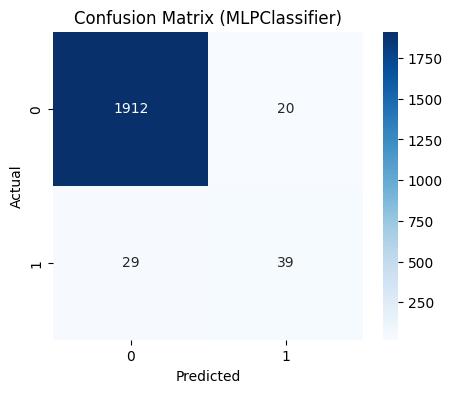


Threshold: 0.10
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1932
           1       0.36      0.82      0.50        68

    accuracy                           0.94      2000
   macro avg       0.68      0.89      0.74      2000
weighted avg       0.97      0.94      0.96      2000

ROC-AUC: 0.9690126050420168
[[1834   98]
 [  12   56]]


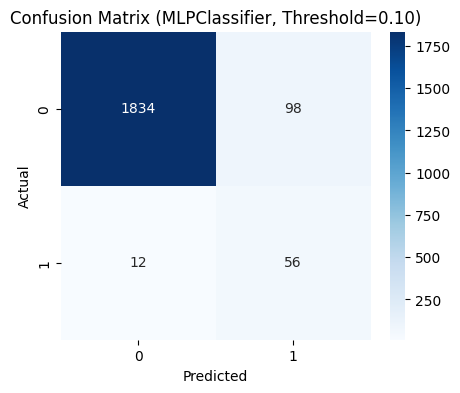


Threshold: 0.20
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.50      0.81      0.62        68

    accuracy                           0.97      2000
   macro avg       0.75      0.89      0.80      2000
weighted avg       0.98      0.97      0.97      2000

ROC-AUC: 0.9690126050420168
[[1877   55]
 [  13   55]]


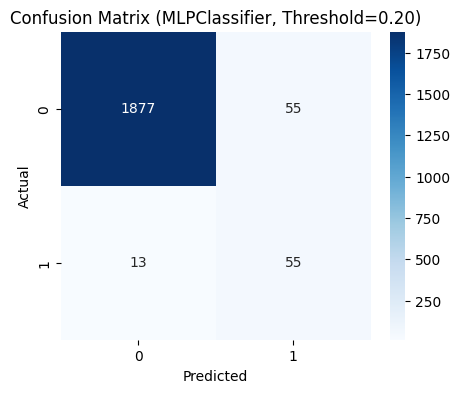


Threshold: 0.30
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.58      0.72      0.64        68

    accuracy                           0.97      2000
   macro avg       0.79      0.85      0.82      2000
weighted avg       0.98      0.97      0.97      2000

ROC-AUC: 0.9690126050420168
[[1897   35]
 [  19   49]]


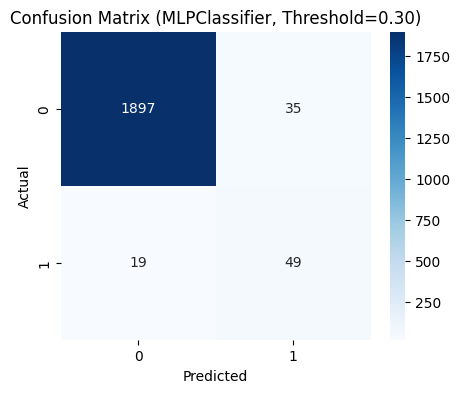


Threshold: 0.40
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.65      0.71      0.68        68

    accuracy                           0.98      2000
   macro avg       0.82      0.85      0.83      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9690126050420168
[[1906   26]
 [  20   48]]


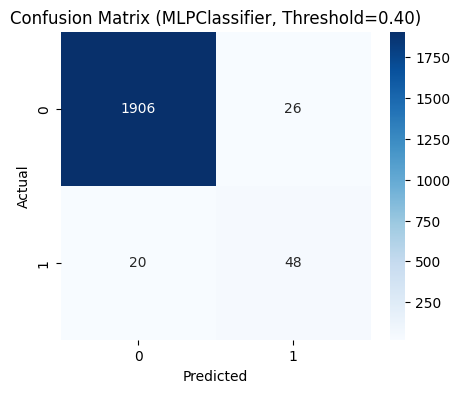


Threshold: 0.50
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.66      0.57      0.61        68

    accuracy                           0.98      2000
   macro avg       0.82      0.78      0.80      2000
weighted avg       0.97      0.98      0.97      2000

ROC-AUC: 0.9690126050420168
[[1912   20]
 [  29   39]]


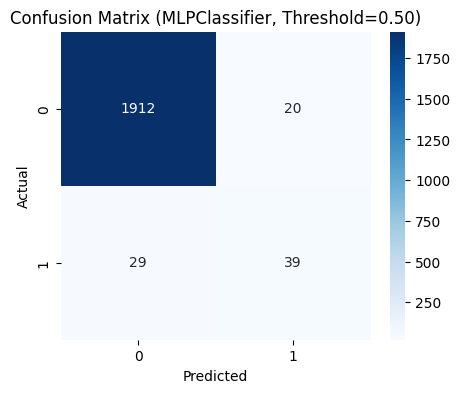


Threshold: 0.60
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.72      0.57      0.64        68

    accuracy                           0.98      2000
   macro avg       0.85      0.78      0.81      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9690126050420168
[[1917   15]
 [  29   39]]


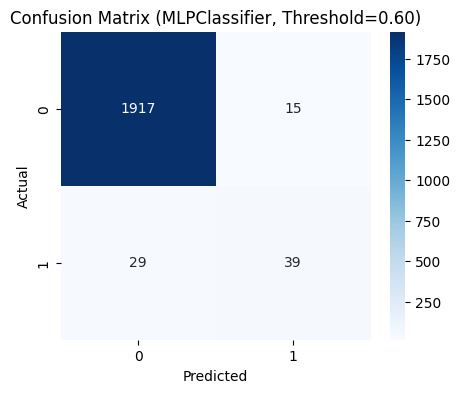


Threshold: 0.70
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.81      0.50      0.62        68

    accuracy                           0.98      2000
   macro avg       0.90      0.75      0.80      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9690126050420168
[[1924    8]
 [  34   34]]


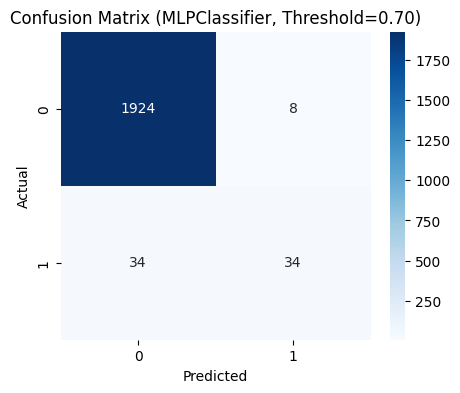


Threshold: 0.80
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.86      0.46      0.60        68

    accuracy                           0.98      2000
   macro avg       0.92      0.73      0.79      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9690126050420168
[[1927    5]
 [  37   31]]


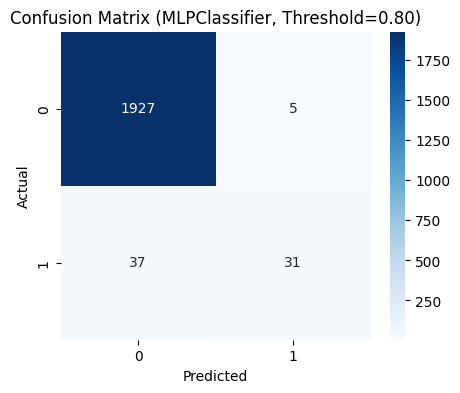


Threshold: 0.90
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.90      0.28      0.43        68

    accuracy                           0.97      2000
   macro avg       0.94      0.64      0.71      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9690126050420168
[[1930    2]
 [  49   19]]


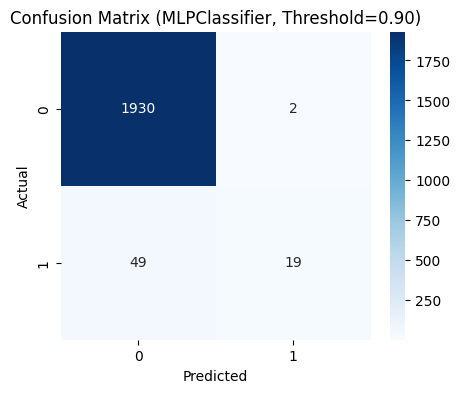

In [ ]:
hidden_configs = [
    (32,),
    (64,),
    (128,),
    (64, 32),
    (128, 64),
    (128, 64, 32),
    (256, 128, 64)
]

alpha_values = [0.0001, 0.001, 0.01]
learning_rates = [0.0005, 0.001, 0.005]

mlp_results = []

for hidden in hidden_configs:
    for alpha in alpha_values:
        for lr in learning_rates:
            mlp = MLPClassifier(
                hidden_layer_sizes=hidden,
                activation="relu",
                solver="adam",
                alpha=alpha,
                learning_rate_init=lr,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=42
            )

            mlp.fit(X_train_scaled, y_train)

            y_val_pred = mlp.predict(X_val_scaled)
            y_val_prob = mlp.predict_proba(X_val_scaled)[:, 1]

            mlp_results.append({
                "hidden_layers": hidden,
                "alpha": alpha,
                "learning_rate": lr,
                "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0),
                "f1": f1_score(y_val, y_val_pred, zero_division=0),
                "roc_auc": roc_auc_score(y_val, y_val_prob)
            })

mlp_results_df = pd.DataFrame(mlp_results)

print(mlp_results_df.sort_values("f1", ascending=False).head(10))

best_row = mlp_results_df.sort_values("f1", ascending=False).iloc[0]

best_hidden = best_row["hidden_layers"]
best_alpha = best_row["alpha"]
best_lr = best_row["learning_rate"]

print("Best hidden layers:", best_hidden)
print("Best alpha:", best_alpha)
print("Best learning rate:", best_lr)
print("Best validation F1:", best_row["f1"])

mlp_best = MLPClassifier(
    hidden_layer_sizes=best_hidden,
    activation="relu",
    solver="adam",
    alpha=best_alpha,
    learning_rate_init=best_lr,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

mlp_best.fit(X_train_scaled, y_train)

y_test_pred_mlp = mlp_best.predict(X_test_scaled)
y_test_prob_mlp = mlp_best.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_test_pred_mlp))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_mlp))

cm_mlp = confusion_matrix(y_test, y_test_pred_mlp)

plt.figure(figsize=(5,4))
sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (MLPClassifier)")
plt.show()

for t in np.linspace(0.1, 0.9, 9):
    preds = (y_test_prob_mlp >= t).astype(int)

    print(f"\nThreshold: {t:.2f}")
    print(classification_report(y_test, preds, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_mlp))
    cm = confusion_matrix(y_test, preds)
    print(cm)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix (MLPClassifier_Sklearn, Threshold={t:.2f})")
    plt.show()

Epoch 10, Train Loss: 0.0858, Val Loss: 0.0862
Epoch 20, Train Loss: 0.0701, Val Loss: 0.0818
Epoch 30, Train Loss: 0.0637, Val Loss: 0.0698
Epoch 40, Train Loss: 0.0567, Val Loss: 0.0639
Epoch 50, Train Loss: 0.0544, Val Loss: 0.0638
Epoch 60, Train Loss: 0.0500, Val Loss: 0.0626
Epoch 70, Train Loss: 0.0449, Val Loss: 0.0622
Epoch 80, Train Loss: 0.0419, Val Loss: 0.0635
Epoch 90, Train Loss: 0.0395, Val Loss: 0.0645
Epoch 100, Train Loss: 0.0431, Val Loss: 0.0636


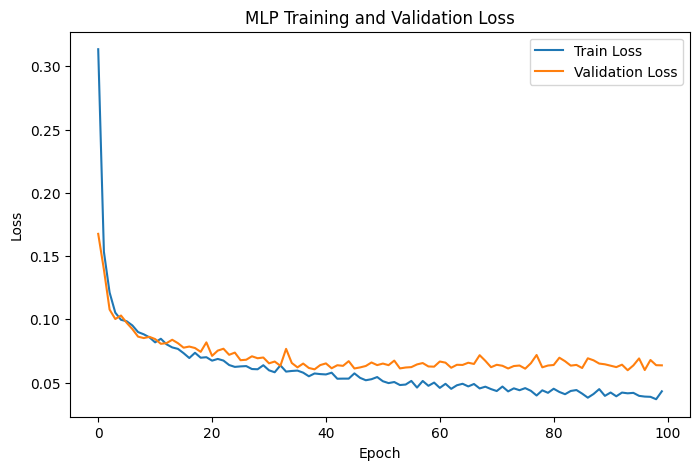

MLP(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [ ]:
# Using Torch

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)


class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes):
        super().__init__()

        layers = []
        prev_size = input_size

        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            prev_size = h

        layers.append(nn.Linear(prev_size, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)
    


input_size = X_train_t.shape[1]

model = MLP(input_size, hidden_sizes=(128, 64, 32))

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []

num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_loss = criterion(val_logits, y_val_t).item()
        val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}")




plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training and Validation Loss")
plt.legend()
plt.show()



model.eval()




PyTorch MLP Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.79      0.62      0.69        68

    accuracy                           0.98      2000
   macro avg       0.89      0.81      0.84      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9724454999391061
[[1921   11]
 [  26   42]]


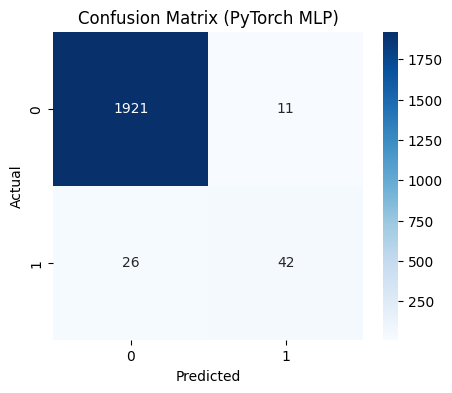

In [192]:
with torch.no_grad():
    test_logits = model(X_test_t)
    test_probs = torch.sigmoid(test_logits).cpu().numpy().flatten()

# default threshold = 0.5
test_preds = (test_probs >= 0.5).astype(int)

print("PyTorch MLP Classification Report:")
print(classification_report(y_test, test_preds))

print("ROC-AUC:", roc_auc_score(y_test, test_probs))

cm = confusion_matrix(y_test, test_preds)
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (PyTorch MLP)")
plt.show()

In [193]:
## Validation with Torch
def train_mlp(hidden_sizes, lr=0.001, epochs=100):
    model = MLP(input_size=X_train_t.shape[1], hidden_sizes=hidden_sizes)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=64,
        shuffle=True
    )

    for epoch in range(epochs):
        model.train()

        for X_batch, y_batch in train_loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_probs = torch.sigmoid(val_logits).numpy()
        val_preds = (val_probs >= 0.5).astype(int)

    return {
        "model": model,
        "hidden_sizes": hidden_sizes,
        "lr": lr,
        "precision": precision_score(y_val, val_preds),
        "recall": recall_score(y_val, val_preds),
        "f1": f1_score(y_val, val_preds),
        "roc_auc": roc_auc_score(y_val, val_probs)
    }

hidden_configs = [
    (32,),
    (64,),
    (128,),
    (64, 32),
    (128, 64),
    (128, 64, 32),
    (256, 128, 64)
]

learning_rates = [0.0005, 0.001, 0.005]

mlp_results = []

for h in hidden_configs:
    for lr in learning_rates:
        result = train_mlp(hidden_sizes=h, lr=lr, epochs=100)
        mlp_results.append(result)

mlp_results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "model"}
    for r in mlp_results
])

print(mlp_results_df.sort_values("f1", ascending=False))


best_index = mlp_results_df.sort_values("f1", ascending=False).index[0]
best_mlp = mlp_results[best_index]["model"]

print("Best MLP config:")
print(mlp_results_df.loc[best_index])

      hidden_sizes      lr  precision    recall        f1   roc_auc
8           (128,)  0.0050   0.843137  0.632353  0.722689  0.952069
18  (256, 128, 64)  0.0005   0.796296  0.632353  0.704918  0.965960
15   (128, 64, 32)  0.0005   0.836735  0.602941  0.700855  0.960754
10        (64, 32)  0.0010   0.836735  0.602941  0.700855  0.959818
14       (128, 64)  0.0050   0.829787  0.573529  0.678261  0.957781
13       (128, 64)  0.0010   0.795918  0.573529  0.666667  0.960997
16   (128, 64, 32)  0.0010   0.822222  0.544118  0.654867  0.957740
20  (256, 128, 64)  0.0050   0.897436  0.514706  0.654206  0.959719
19  (256, 128, 64)  0.0010   0.804348  0.544118  0.649123  0.962223
5            (64,)  0.0050   0.916667  0.485294  0.634615  0.951825
17   (128, 64, 32)  0.0050   0.777778  0.514706  0.619469  0.967939
9         (64, 32)  0.0005   0.804878  0.485294  0.605505  0.947281
11        (64, 32)  0.0050   0.692308  0.529412  0.600000  0.953150
12       (128, 64)  0.0005   0.909091  0.441176 

Best MLP Test Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1932
           1       0.77      0.53      0.63        68

    accuracy                           0.98      2000
   macro avg       0.87      0.76      0.81      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9635473754719279
[[1921   11]
 [  32   36]]


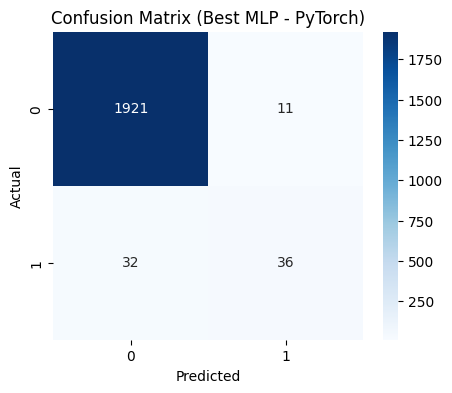

In [194]:
best_mlp.eval()
with torch.no_grad():
    test_logits = best_mlp(X_test_t)
    test_probs = torch.sigmoid(test_logits).cpu().numpy().flatten()
test_preds = (test_probs >= 0.5).astype(int)
print("Best MLP Test Classification Report:")
print(classification_report(y_test, test_preds))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
cm = confusion_matrix(y_test, test_preds)
print(cm)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Best MLP - PyTorch)")
plt.show()



Threshold: 0.10
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.51      0.82      0.63        68

    accuracy                           0.97      2000
   macro avg       0.75      0.90      0.81      2000
weighted avg       0.98      0.97      0.97      2000

ROC-AUC: 0.9635473754719279
[[1878   54]
 [  12   56]]


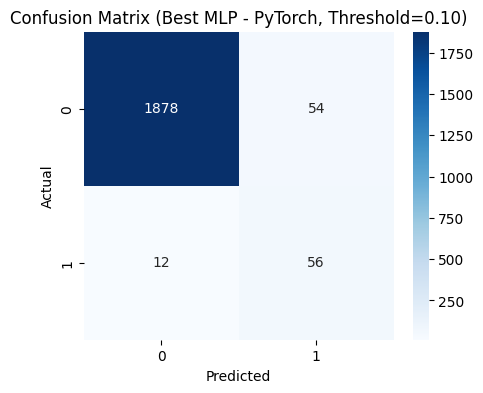


Threshold: 0.20
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.65      0.75      0.70        68

    accuracy                           0.98      2000
   macro avg       0.82      0.87      0.84      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9635473754719279
[[1905   27]
 [  17   51]]


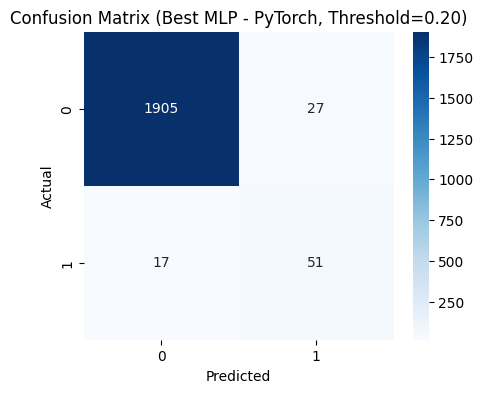


Threshold: 0.30
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.68      0.68      0.68        68

    accuracy                           0.98      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9635473754719279
[[1910   22]
 [  22   46]]


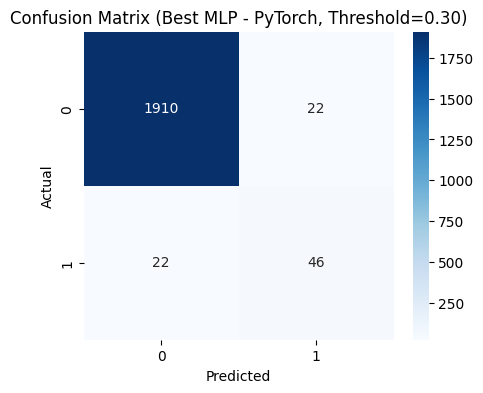


Threshold: 0.40
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1932
           1       0.70      0.56      0.62        68

    accuracy                           0.98      2000
   macro avg       0.84      0.78      0.81      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9635473754719279
[[1916   16]
 [  30   38]]


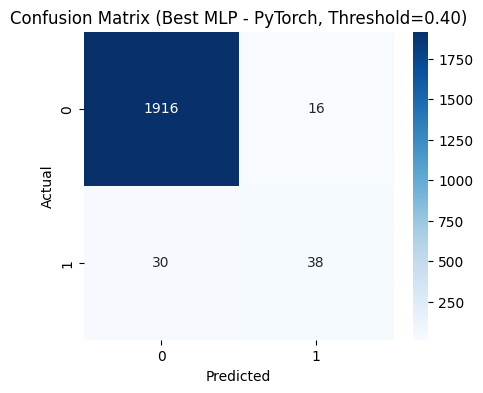


Threshold: 0.50
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1932
           1       0.77      0.53      0.63        68

    accuracy                           0.98      2000
   macro avg       0.87      0.76      0.81      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9635473754719279
[[1921   11]
 [  32   36]]


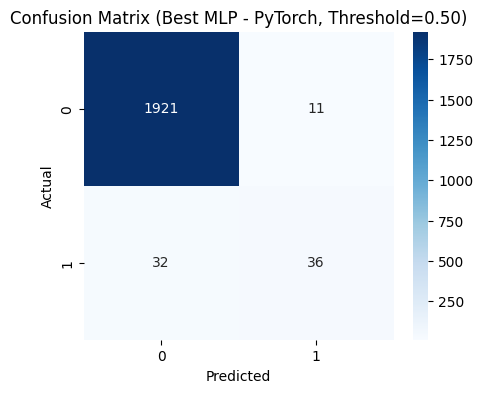


Threshold: 0.60
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.81      0.51      0.63        68

    accuracy                           0.98      2000
   macro avg       0.90      0.76      0.81      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9635473754719279
[[1924    8]
 [  33   35]]


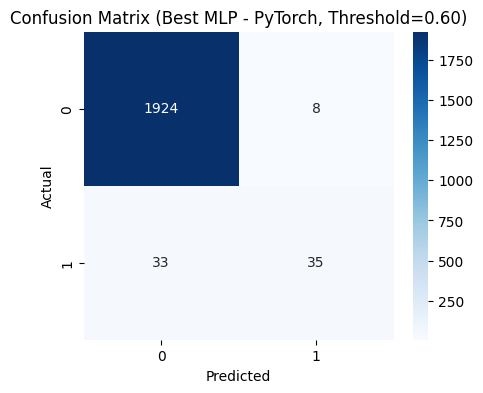


Threshold: 0.70
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.87      0.49      0.62        68

    accuracy                           0.98      2000
   macro avg       0.93      0.74      0.81      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9635473754719279
[[1927    5]
 [  35   33]]


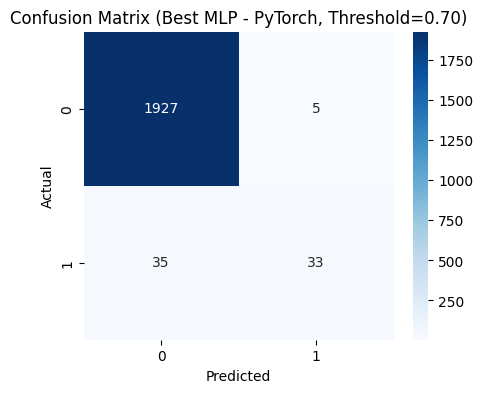


Threshold: 0.80
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.87      0.38      0.53        68

    accuracy                           0.98      2000
   macro avg       0.92      0.69      0.76      2000
weighted avg       0.97      0.98      0.97      2000

ROC-AUC: 0.9635473754719279
[[1928    4]
 [  42   26]]


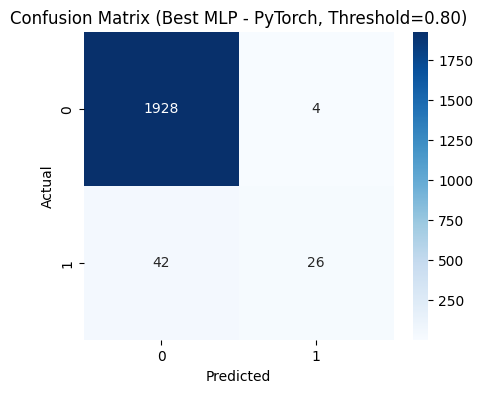


Threshold: 0.90
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.92      0.34      0.49        68

    accuracy                           0.98      2000
   macro avg       0.95      0.67      0.74      2000
weighted avg       0.98      0.98      0.97      2000

ROC-AUC: 0.9635473754719279
[[1930    2]
 [  45   23]]


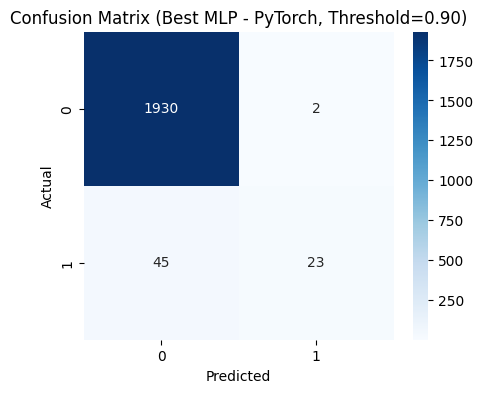

In [195]:
thresholds = np.linspace(0.1, 0.9, 9)

for t in thresholds:
    preds = (test_probs >= t).astype(int)
    
    print(f"\nThreshold: {t:.2f}")
    print(classification_report(y_test, preds, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_test, test_probs))
    cm = confusion_matrix(y_test, preds)
    print(cm)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix (Best MLP - PyTorch, Threshold={t:.2f})")
    plt.show()
    

## Random Forest Classifier

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1932
           1       0.92      0.18      0.30        68

    accuracy                           0.97      2000
   macro avg       0.95      0.59      0.64      2000
weighted avg       0.97      0.97      0.96      2000

ROC-AUC: 0.960072616002923
[[1931    1]
 [  56   12]]


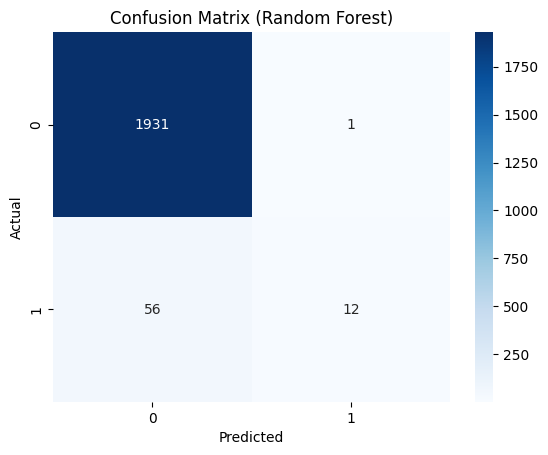

In [196]:
Random_forest = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42,)
Random_forest.fit(X_train_scaled, y_train)
y_pred_rf = Random_forest.predict(X_test_scaled)
y_prob_rf = Random_forest.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest)")
plt.show()

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1932
           1       0.38      0.85      0.53        68

    accuracy                           0.95      2000
   macro avg       0.69      0.90      0.75      2000
weighted avg       0.97      0.95      0.96      2000

ROC-AUC: 0.9546492510047497
[[1839   93]
 [  10   58]]


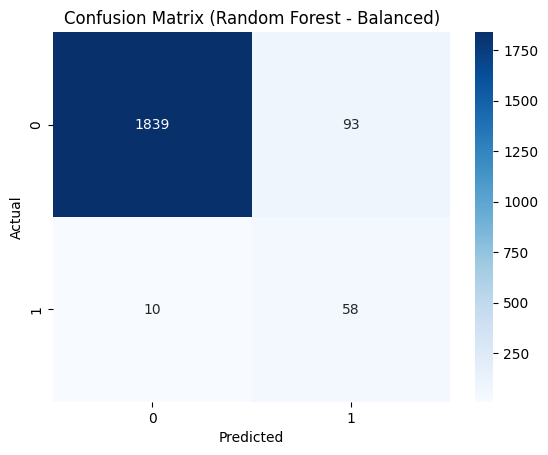

In [197]:
Random_forest_balanced = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
Random_forest_balanced.fit(X_train_scaled, y_train)
y_pred_rf_balanced = Random_forest_balanced.predict(X_test_scaled)
y_prob_rf_balanced = Random_forest_balanced.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred_rf_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_balanced))
cm = confusion_matrix(y_test, y_pred_rf_balanced)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest - Balanced)")
plt.show()

   n_estimators  max_depth  precision    recall        f1   roc_auc
4           100         10   0.586207  0.500000  0.539683  0.966512
1            50         10   0.576271  0.500000  0.535433  0.960202
5           100         15   0.812500  0.382353  0.520000  0.966672
7           200         10   0.571429  0.470588  0.516129  0.967178
2            50         15   0.833333  0.367647  0.510204  0.945789
8           200         15   0.774194  0.352941  0.484848  0.965325
0            50          5   0.344828  0.735294  0.469484  0.958154
3           100          5   0.318750  0.750000  0.447368  0.958455
6           200          5   0.314815  0.750000  0.443478  0.960122
100 10
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1932
           1       0.61      0.56      0.58        68

    accuracy                           0.97      2000
   macro avg       0.80      0.77      0.79      2000
weighted avg       0.97      0.97      0.

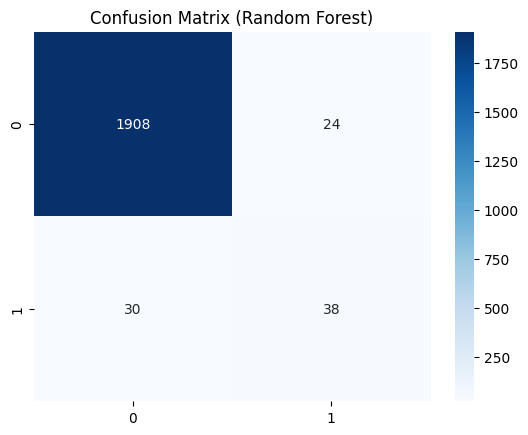

               Feature  Importance
3               Torque    0.336022
2     Rotational speed    0.275767
4            Tool wear    0.182657
0      Air temperature    0.117073
1  Process temperature    0.074949
5               Type_L    0.006894
6               Type_M    0.006638


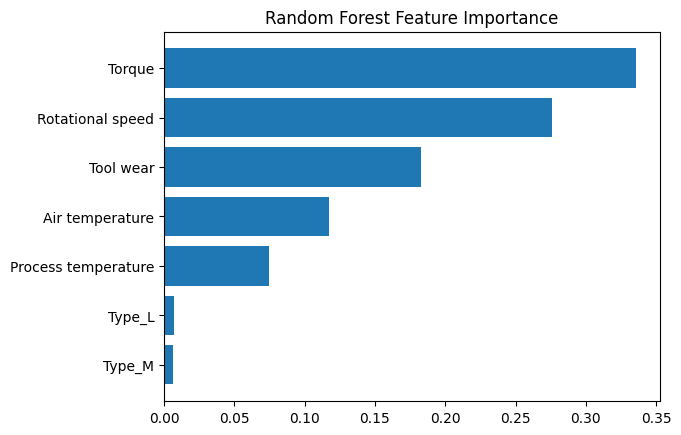


Threshold: 0.10
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      1932
           1       0.29      0.90      0.44        68

    accuracy                           0.92      2000
   macro avg       0.64      0.91      0.70      2000
weighted avg       0.97      0.92      0.94      2000

ROC-AUC: 0.9647157776153941
[[1781  151]
 [   7   61]]


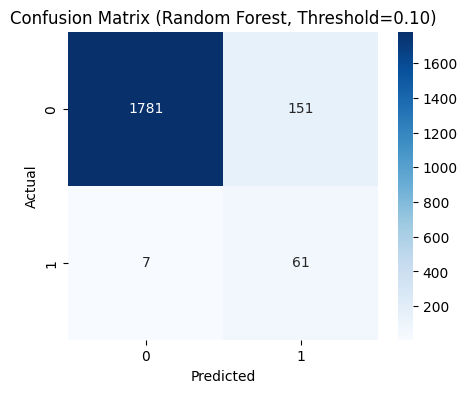


Threshold: 0.20
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1932
           1       0.41      0.85      0.56        68

    accuracy                           0.95      2000
   macro avg       0.70      0.90      0.77      2000
weighted avg       0.97      0.95      0.96      2000

ROC-AUC: 0.9647157776153941
[[1849   83]
 [  10   58]]


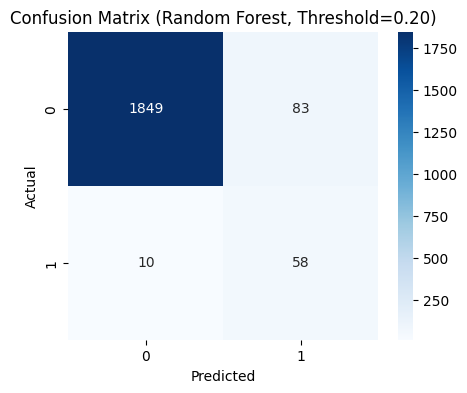


Threshold: 0.30
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1932
           1       0.55      0.78      0.65        68

    accuracy                           0.97      2000
   macro avg       0.77      0.88      0.82      2000
weighted avg       0.98      0.97      0.97      2000

ROC-AUC: 0.9647157776153941
[[1889   43]
 [  15   53]]


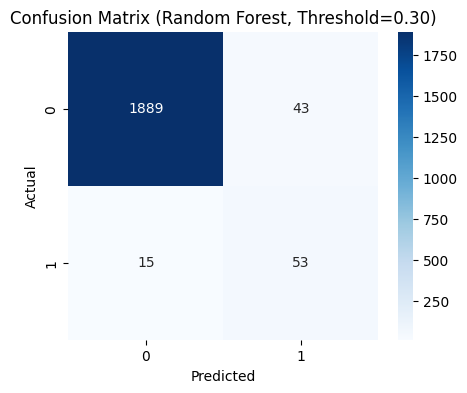


Threshold: 0.40
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.58      0.63      0.61        68

    accuracy                           0.97      2000
   macro avg       0.78      0.81      0.80      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9647157776153941
[[1901   31]
 [  25   43]]


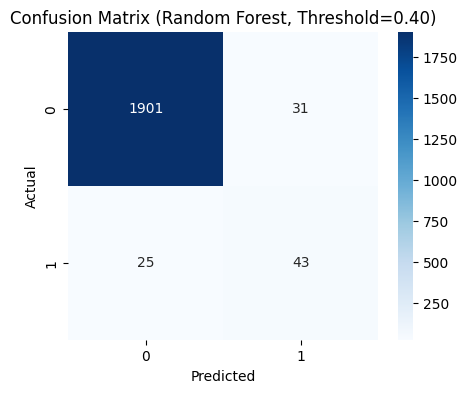


Threshold: 0.50
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1932
           1       0.61      0.56      0.58        68

    accuracy                           0.97      2000
   macro avg       0.80      0.77      0.79      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9647157776153941
[[1908   24]
 [  30   38]]


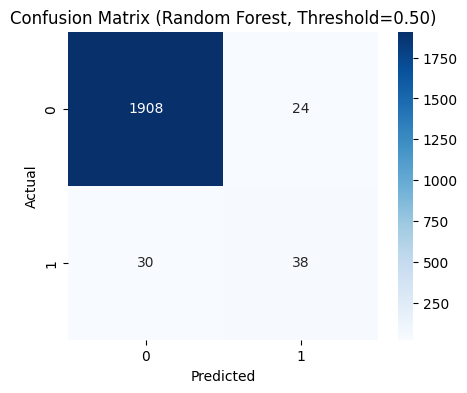


Threshold: 0.60
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1932
           1       0.65      0.46      0.53        68

    accuracy                           0.97      2000
   macro avg       0.81      0.72      0.76      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9647157776153941
[[1915   17]
 [  37   31]]


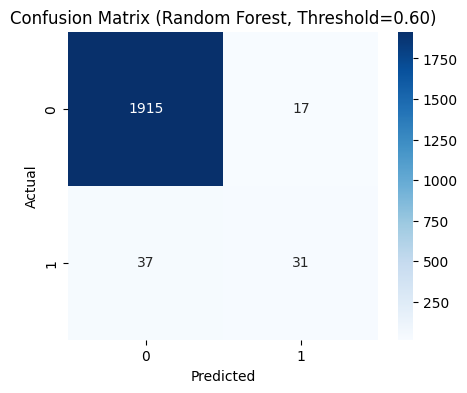


Threshold: 0.70
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.74      0.34      0.46        68

    accuracy                           0.97      2000
   macro avg       0.86      0.67      0.73      2000
weighted avg       0.97      0.97      0.97      2000

ROC-AUC: 0.9647157776153941
[[1924    8]
 [  45   23]]


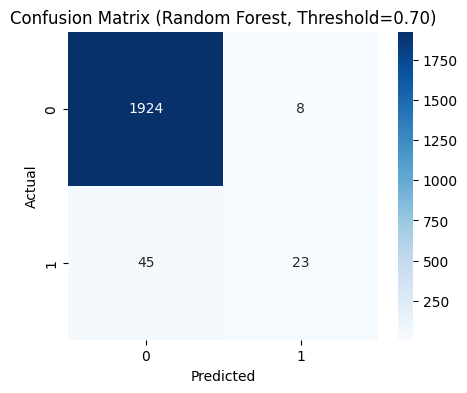


Threshold: 0.80
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1932
           1       0.93      0.19      0.32        68

    accuracy                           0.97      2000
   macro avg       0.95      0.60      0.65      2000
weighted avg       0.97      0.97      0.96      2000

ROC-AUC: 0.9647157776153941
[[1931    1]
 [  55   13]]


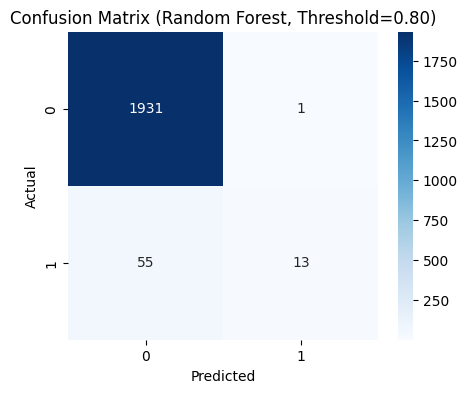


Threshold: 0.90
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.00      0.00      0.00        68

    accuracy                           0.97      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.93      0.97      0.95      2000

ROC-AUC: 0.9647157776153941
[[1932    0]
 [  68    0]]


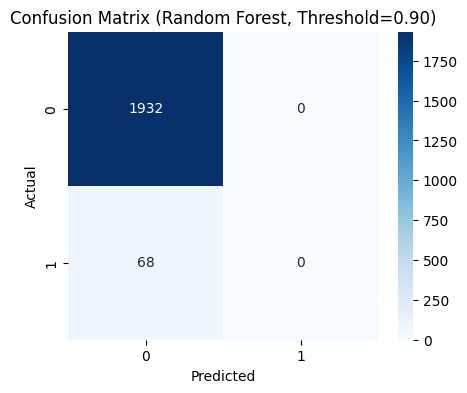

In [198]:
from sklearn.ensemble import RandomForestClassifier

n_estimators_values = [50, 100, 200]
depth_values = [5, 10, 15]

rf_results = []

for n in n_estimators_values:
    for d in depth_values:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=d,
            random_state=42,
            class_weight="balanced"
        )

        rf.fit(X_train_scaled, y_train)

        y_val_pred = rf.predict(X_val_scaled)
        y_val_prob = rf.predict_proba(X_val_scaled)[:, 1]

        rf_results.append({
            "n_estimators": n,
            "max_depth": d,
            "precision": precision_score(y_val, y_val_pred),
            "recall": recall_score(y_val, y_val_pred),
            "f1": f1_score(y_val, y_val_pred),
            "roc_auc": roc_auc_score(y_val, y_val_prob)
        })

rf_results_df = pd.DataFrame(rf_results)

print(rf_results_df.sort_values("f1", ascending=False))



best_row = rf_results_df.sort_values("f1", ascending=False).iloc[0]

best_n = int(best_row["n_estimators"])
best_depth = int(best_row["max_depth"])

print(best_n, best_depth)

rf_best = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=best_depth,
    random_state=42,
    class_weight="balanced"
)

rf_best.fit(X_train_scaled, y_train)

y_test_pred_rf = rf_best.predict(X_test_scaled)
y_test_prob_rf = rf_best.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_test_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_rf))


cm_rf = confusion_matrix(y_test, y_test_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Random Forest)")
plt.show()


rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_best.feature_importances_
}).sort_values("Importance", ascending=False)

print(rf_importance)

plt.barh(rf_importance["Feature"], rf_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.show()


thresholds = np.linspace(0.1, 0.9, 9)

for t in thresholds:
    preds = (y_test_prob_rf >= t).astype(int)

    print(f"\nThreshold: {t:.2f}")
    print(classification_report(y_test, preds, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_rf))
    cm = confusion_matrix(y_test, preds)
    print(cm)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix (Random Forest, Threshold={t:.2f})")
    plt.show()
    

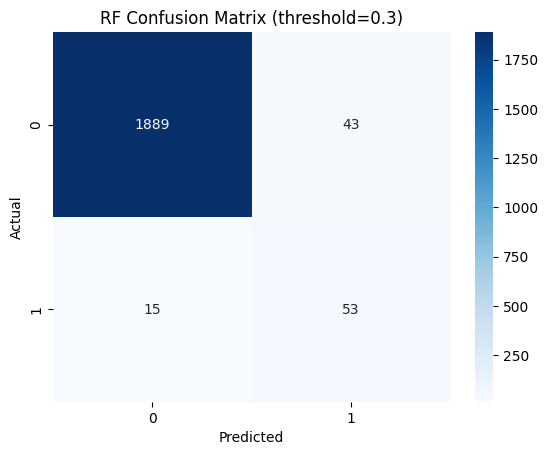

In [199]:
t = 0.3 

rf_preds = (y_test_prob_rf >= t).astype(int)

cm_rf = confusion_matrix(y_test, rf_preds)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title(f"RF Confusion Matrix (threshold={t})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## XGBoost

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.80      0.63      0.70        68

    accuracy                           0.98      2000
   macro avg       0.89      0.81      0.85      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9611268420411644
[[1921   11]
 [  25   43]]


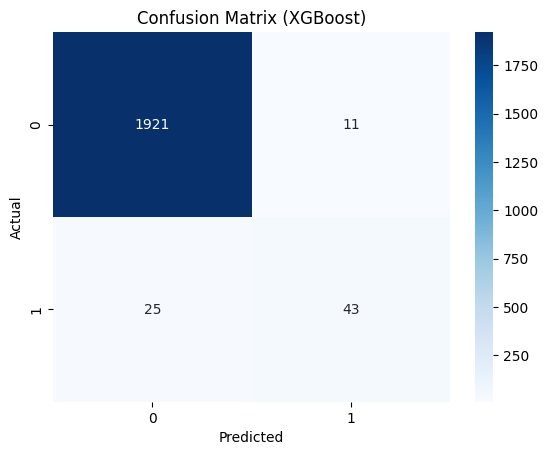

In [200]:
Xgb= XGBClassifier(n_estimators=100, max_depth=5, random_state=42)
Xgb.fit(X_train_scaled, y_train)
y_pred_xgb = Xgb.predict(X_test_scaled)
y_prob_xgb = Xgb.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
cm = confusion_matrix(y_test, y_pred_xgb)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (XGBoost)")
plt.show()

    n_estimators  max_depth  learning_rate  precision    recall        f1  \
12           200          5           0.05   0.883721  0.558824  0.684685   
4            100          5           0.10   0.847826  0.573529  0.684211   
17           200          7           0.20   0.847826  0.573529  0.684211   
15           200          7           0.05   0.902439  0.544118  0.678899   
13           200          5           0.10   0.829787  0.573529  0.678261   
7            100          7           0.10   0.880952  0.544118  0.672727   
8            100          7           0.20   0.844444  0.558824  0.672566   
14           200          5           0.20   0.844444  0.558824  0.672566   
6            100          7           0.05   0.878049  0.529412  0.660550   
16           200          7           0.10   0.857143  0.529412  0.654545   
5            100          5           0.20   0.857143  0.529412  0.654545   
3            100          5           0.05   0.857143  0.529412  0.654545   

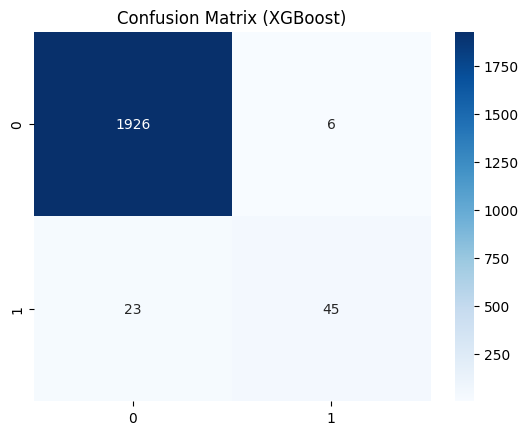

               Feature  Importance
3               Torque    0.271382
2     Rotational speed    0.174128
4            Tool wear    0.162411
0      Air temperature    0.147041
1  Process temperature    0.105095
5               Type_L    0.083208
6               Type_M    0.056736


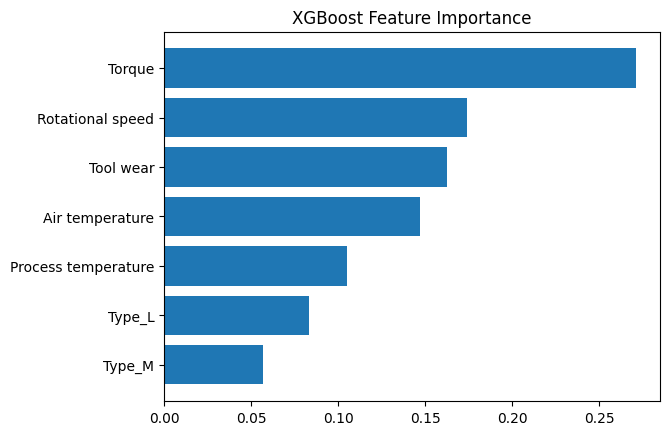


Threshold: 0.10
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.53      0.85      0.65        68

    accuracy                           0.97      2000
   macro avg       0.76      0.91      0.82      2000
weighted avg       0.98      0.97      0.97      2000

ROC-AUC: 0.9745158933138474
[[1880   52]
 [  10   58]]


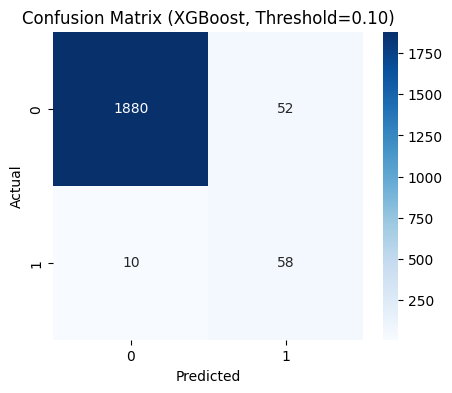


Threshold: 0.20
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.72      0.78      0.75        68

    accuracy                           0.98      2000
   macro avg       0.85      0.88      0.87      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9745158933138474
[[1911   21]
 [  15   53]]


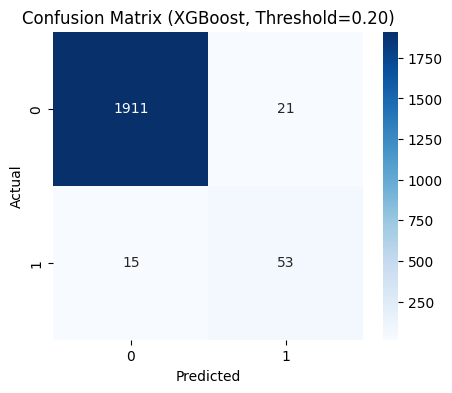


Threshold: 0.30
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.80      0.76      0.78        68

    accuracy                           0.99      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9745158933138474
[[1919   13]
 [  16   52]]


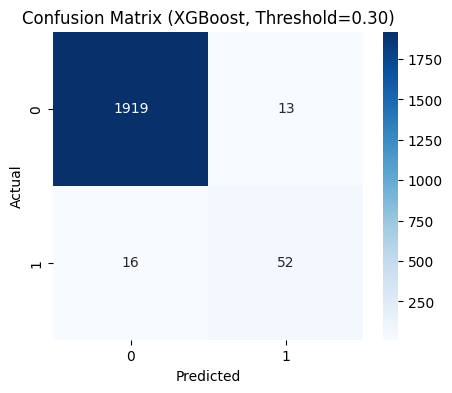


Threshold: 0.40
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.85      0.74      0.79        68

    accuracy                           0.99      2000
   macro avg       0.92      0.87      0.89      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9745158933138474
[[1923    9]
 [  18   50]]


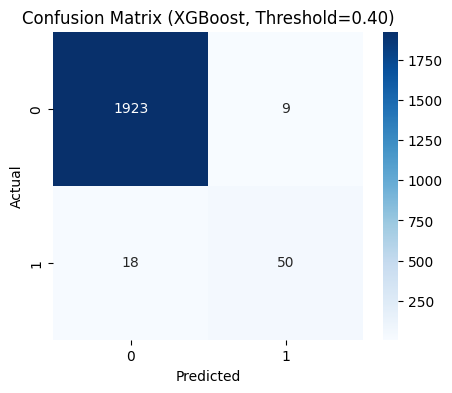


Threshold: 0.50
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.88      0.66      0.76        68

    accuracy                           0.99      2000
   macro avg       0.94      0.83      0.87      2000
weighted avg       0.98      0.99      0.98      2000

ROC-AUC: 0.9745158933138474
[[1926    6]
 [  23   45]]


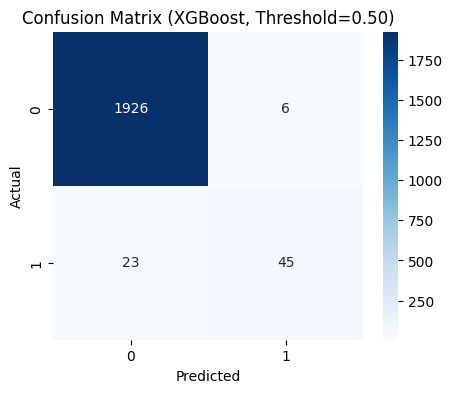


Threshold: 0.60
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.93      0.54      0.69        68

    accuracy                           0.98      2000
   macro avg       0.95      0.77      0.84      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9745158933138474
[[1929    3]
 [  31   37]]


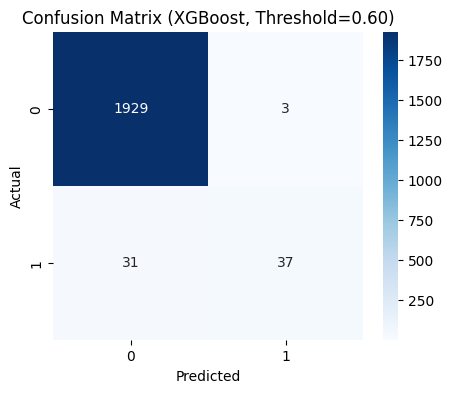


Threshold: 0.70
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.97      0.46      0.62        68

    accuracy                           0.98      2000
   macro avg       0.97      0.73      0.81      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.9745158933138474
[[1931    1]
 [  37   31]]


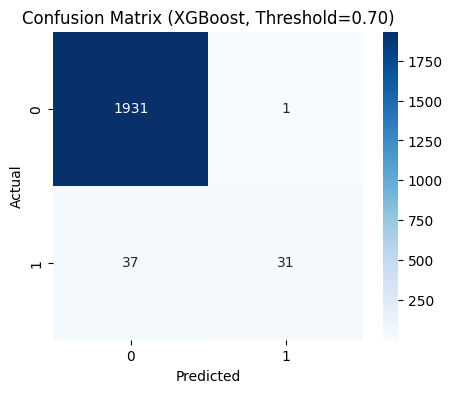


Threshold: 0.80
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       1.00      0.38      0.55        68

    accuracy                           0.98      2000
   macro avg       0.99      0.69      0.77      2000
weighted avg       0.98      0.98      0.97      2000

ROC-AUC: 0.9745158933138474
[[1932    0]
 [  42   26]]


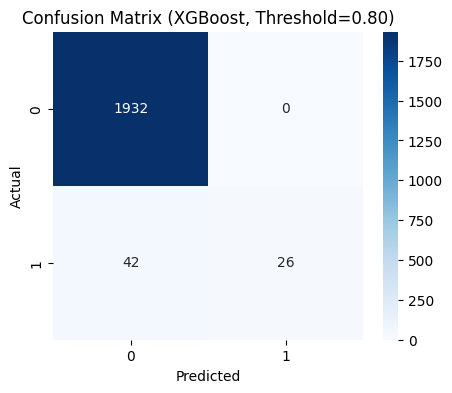


Threshold: 0.90
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1932
           1       1.00      0.15      0.26        68

    accuracy                           0.97      2000
   macro avg       0.99      0.57      0.62      2000
weighted avg       0.97      0.97      0.96      2000

ROC-AUC: 0.9745158933138474
[[1932    0]
 [  58   10]]


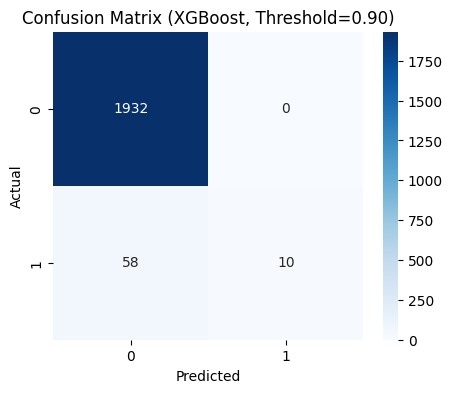

In [201]:
from xgboost import XGBClassifier

xgb_results = []

n_estimators_values = [100, 200]
depth_values = [3, 5, 7]
learning_rates = [0.05, 0.1, 0.2]

for n in n_estimators_values:
    for d in depth_values:
        for lr in learning_rates:
            xgb = XGBClassifier(
                n_estimators=n,
                max_depth=d,
                learning_rate=lr,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42
            )

            xgb.fit(X_train_scaled, y_train)

            y_val_pred = xgb.predict(X_val_scaled)
            y_val_prob = xgb.predict_proba(X_val_scaled)[:, 1]

            xgb_results.append({
                "n_estimators": n,
                "max_depth": d,
                "learning_rate": lr,
                "precision": precision_score(y_val, y_val_pred),
                "recall": recall_score(y_val, y_val_pred),
                "f1": f1_score(y_val, y_val_pred),
                "roc_auc": roc_auc_score(y_val, y_val_prob)
            })

xgb_results_df = pd.DataFrame(xgb_results)

print(xgb_results_df.sort_values("f1", ascending=False))



best_row = xgb_results_df.sort_values("f1", ascending=False).iloc[0]

best_n = int(best_row["n_estimators"])
best_depth = int(best_row["max_depth"])
best_lr = best_row["learning_rate"]

print(best_row)



xgb_best = XGBClassifier(
    n_estimators=best_n,
    max_depth=best_depth,
    learning_rate=best_lr,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_best.fit(X_train_scaled, y_train)


y_test_pred_xgb = xgb_best.predict(X_test_scaled)
y_test_prob_xgb = xgb_best.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_test_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_xgb))
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (XGBoost)")
plt.show()



xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_best.feature_importances_
}).sort_values("Importance", ascending=False)

print(xgb_importance)

plt.barh(xgb_importance["Feature"], xgb_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()



for t in np.linspace(0.1, 0.9, 9):
    preds = (y_test_prob_xgb >= t).astype(int)

    print(f"\nThreshold: {t:.2f}")
    print(classification_report(y_test, preds, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_xgb))
    cm = confusion_matrix(y_test, preds)
    print(cm)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix (XGBoost, Threshold={t:.2f})")
    plt.show()

## Final Comparison


===== Random Forest @ threshold 0.1 =====
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      1932
           1       0.29      0.90      0.44        68

    accuracy                           0.92      2000
   macro avg       0.64      0.91      0.70      2000
weighted avg       0.97      0.92      0.94      2000

Confusion Matrix:
 [[1781  151]
 [   7   61]]


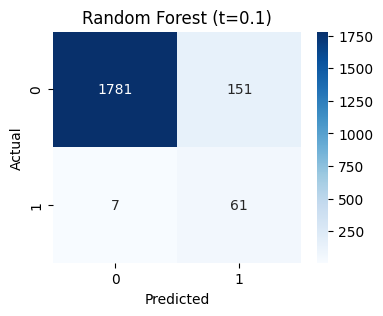


===== Random Forest @ threshold 0.3 =====
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1932
           1       0.55      0.78      0.65        68

    accuracy                           0.97      2000
   macro avg       0.77      0.88      0.82      2000
weighted avg       0.98      0.97      0.97      2000

Confusion Matrix:
 [[1889   43]
 [  15   53]]


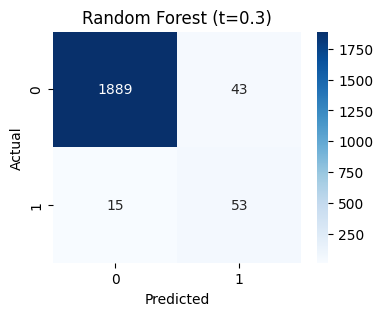


===== XGBoost @ threshold 0.1 =====
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.53      0.85      0.65        68

    accuracy                           0.97      2000
   macro avg       0.76      0.91      0.82      2000
weighted avg       0.98      0.97      0.97      2000

Confusion Matrix:
 [[1880   52]
 [  10   58]]


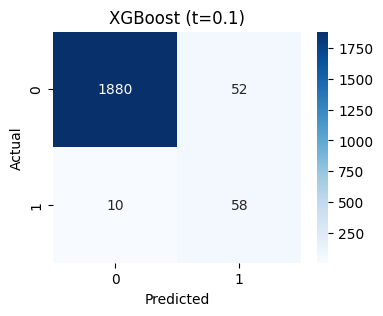


===== XGBoost @ threshold 0.3 =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.80      0.76      0.78        68

    accuracy                           0.99      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.99      0.99      0.99      2000

Confusion Matrix:
 [[1919   13]
 [  16   52]]


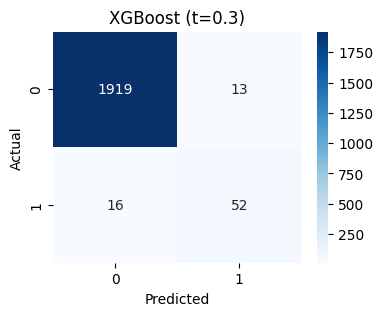


===== MLP @ threshold 0.1 =====
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1932
           1       0.36      0.82      0.50        68

    accuracy                           0.94      2000
   macro avg       0.68      0.89      0.74      2000
weighted avg       0.97      0.94      0.96      2000

Confusion Matrix:
 [[1834   98]
 [  12   56]]


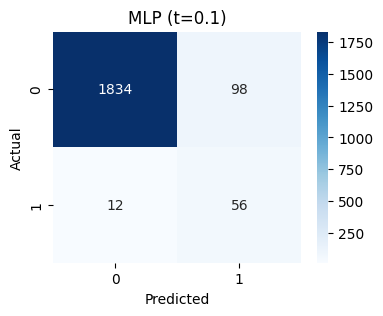


===== MLP @ threshold 0.3 =====
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.58      0.72      0.64        68

    accuracy                           0.97      2000
   macro avg       0.79      0.85      0.82      2000
weighted avg       0.98      0.97      0.97      2000

Confusion Matrix:
 [[1897   35]
 [  19   49]]


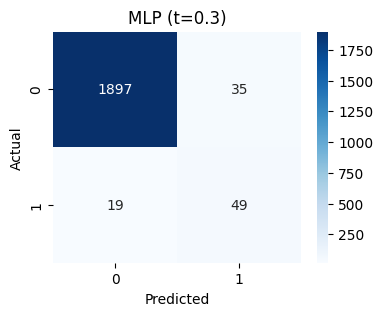

In [202]:
models_probs = {
    "Random Forest": y_test_prob_rf,
    "XGBoost": y_test_prob_xgb,
    "MLP": y_test_prob_mlp
}

thresholds = [0.1, 0.3]

for model_name, probs in models_probs.items():
    for t in thresholds:
        preds = (probs >= t).astype(int)

        print(f"\n===== {model_name} @ threshold {t} =====")
        print(classification_report(y_test, preds, zero_division=0))

        cm = confusion_matrix(y_test, preds)
        print("Confusion Matrix:\n", cm)
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"{model_name} (t={t})")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

In [203]:
print("ROC-AUC Scores:")
print("Logistic Regression (Balanced):", roc_auc_score(y_test, y_prob_balanced))
print("Decision Tree (Balanced):", roc_auc_score(y_test, y_prob_dt_balanced))
print("MLP Classifier:", roc_auc_score(y_test, y_prob_mlp))
print("Random Forest:", roc_auc_score(y_test, y_prob_rf))
print("Random Forest (Balanced):", roc_auc_score(y_test, y_prob_rf_balanced))
print("XGBoost:", roc_auc_score(y_test, y_prob_xgb))

print("Classification Scores:")
print("Logistic Regression (Balanced):", classification_report(y_test, y_pred_balanced))
print("Decision Tree (Balanced):", classification_report(y_test, y_pred_dt_balanced))
print("MLP Classifier:", classification_report(y_test, y_pred_mlp))
print("Random Forest:", classification_report(y_test, y_pred_rf))
print("Random Forest (Balanced):", classification_report(y_test, y_pred_rf_balanced))
print("XGBoost:", classification_report(y_test, y_pred_xgb))



ROC-AUC Scores:
Logistic Regression (Balanced): 0.9037114845938377
Decision Tree (Balanced): 0.8910189075630252
MLP Classifier: 0.9619412982584338
Random Forest: 0.960072616002923
Random Forest (Balanced): 0.9546492510047497
XGBoost: 0.9611268420411644
Classification Scores:
Logistic Regression (Balanced):               precision    recall  f1-score   support

           0       0.99      0.83      0.91      1932
           1       0.15      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.58      2000
weighted avg       0.96      0.83      0.88      2000

Decision Tree (Balanced):               precision    recall  f1-score   support

           0       0.99      0.94      0.97      1932
           1       0.34      0.85      0.49        68

    accuracy                           0.94      2000
   macro avg       0.67      0.90      0.73      2000
weighted avg       0.97      0.94      0.95      2000

MLP Classifi

In [211]:
t = 0.3

comparison = []

models_probs = {
    "Logistic Regression": y_test_prob,
    "Decision Tree": y_test_prob_dt,   
    "MLP (Sklearn)": y_test_prob_mlp,    
    "MLP (PyTorch)": test_probs,
    "Random Forest": y_test_prob_rf,
    "XGBoost": y_test_prob_xgb
}

for name, probs in models_probs.items():
    preds = (probs >= t).astype(int)

    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc = roc_auc_score(y_test, probs)

    comparison.append({
        "Model": name,
        "Precision (Failure)": precision,
        "Recall (Failure)": recall,
        "F1 (Failure)": f1,
        "ROC-AUC": roc
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.sort_values(by="F1 (Failure)", ascending=False))
comparison_df = comparison_df.sort_values(by="F1 (Failure)", ascending=False)
comparison_df.style.background_gradient(cmap="Blues")

                 Model  Precision (Failure)  Recall (Failure)  F1 (Failure)  \
5              XGBoost             0.800000          0.764706      0.781955   
3        MLP (PyTorch)             0.676471          0.676471      0.676471   
4        Random Forest             0.552083          0.779412      0.646341   
2        MLP (Sklearn)             0.583333          0.720588      0.644737   
1        Decision Tree             0.586667          0.647059      0.615385   
0  Logistic Regression             0.092424          0.897059      0.167582   

    ROC-AUC  
5  0.974516  
3  0.963547  
4  0.964716  
2  0.969013  
1  0.816511  
0  0.903711  


,Model,Precision (Failure),Recall (Failure),F1 (Failure),ROC-AUC
5,XGBoost,0.800000,0.764706,0.781955,0.974516
3,MLP (PyTorch),0.676471,0.676471,0.676471,0.963547
4,Random Forest,0.552083,0.779412,0.646341,0.964716
2,MLP (Sklearn),0.583333,0.720588,0.644737,0.969013
1,Decision Tree,0.586667,0.647059,0.615385,0.816511
0,Logistic Regression,0.092424,0.897059,0.167582,0.903711


In [212]:
t = 0.1

comparison = []

models_probs = {
    "Logistic Regression": y_test_prob,
    "Decision Tree": y_test_prob_dt,   
    "MLP (Sklearn)": y_test_prob_mlp,  
    "MLP (PyTorch)": test_probs, 
    "Random Forest": y_test_prob_rf,
    "XGBoost": y_test_prob_xgb
}

for name, probs in models_probs.items():
    preds = (probs >= t).astype(int)

    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc = roc_auc_score(y_test, probs)

    comparison.append({
        "Model": name,
        "Precision (Failure)": precision,
        "Recall (Failure)": recall,
        "F1 (Failure)": f1,
        "ROC-AUC": roc
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.sort_values(by="F1 (Failure)", ascending=False))
comparison_df = comparison_df.sort_values(by="F1 (Failure)", ascending=False)
comparison_df.style.background_gradient(cmap="Blues")

                 Model  Precision (Failure)  Recall (Failure)  F1 (Failure)  \
5              XGBoost             0.527273          0.852941      0.651685   
3        MLP (PyTorch)             0.509091          0.823529      0.629213   
1        Decision Tree             0.586667          0.647059      0.615385   
2        MLP (Sklearn)             0.363636          0.823529      0.504505   
4        Random Forest             0.287736          0.897059      0.435714   
0  Logistic Regression             0.054783          0.985294      0.103796   

    ROC-AUC  
5  0.974516  
3  0.963547  
1  0.816511  
2  0.969013  
4  0.964716  
0  0.903711  


,Model,Precision (Failure),Recall (Failure),F1 (Failure),ROC-AUC
5,XGBoost,0.527273,0.852941,0.651685,0.974516
3,MLP (PyTorch),0.509091,0.823529,0.629213,0.963547
1,Decision Tree,0.586667,0.647059,0.615385,0.816511
2,MLP (Sklearn),0.363636,0.823529,0.504505,0.969013
4,Random Forest,0.287736,0.897059,0.435714,0.964716
0,Logistic Regression,0.054783,0.985294,0.103796,0.903711
